In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import ranksums
from scipy.stats import sem

In [80]:
# Load the re-uploaded file
top_arms = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Arm_Hits/Continuous_Top_Arms_table.csv")
top_arms.head()

,MergeBy,TumorType,Arm,Event,Z_val,P_val,ImmuneCold,ImmuneHot,has_diff_signs,Signif,ColdHits,HotHits,AllHits,Cold_SignedLogP,Hot_SignedLogP
0,ACC_1p,ACC,1p,Gain,0.0,1.000000,False,False,True,False,0,0,NaN,0.0,0.0
1,ACC_1p,ACC,1p,Loss,0.0,0.794876,False,False,True,False,0,0,NaN,0.0,0.0
2,ACC_1q,ACC,1q,Gain,0.0,0.226572,False,False,True,False,0,0,NaN,0.0,0.0
3,ACC_1q,ACC,1q,Loss,0.0,0.791061,False,False,True,False,0,0,NaN,0.0,0.0
4,ACC_2p,ACC,2p,Gain,0.0,0.993692,False,False,True,False,0,0,NaN,0.0,0.0


In [81]:
# Filter using Signif == True
signif_df_flag = top_arms[top_arms["Signif"] == True]

# Filter using P_val < 0.05
signif_df_pval = top_arms[top_arms["P_val"] < 0.05]

# Check if they are exactly the same
signif_df_flag.equals(signif_df_pval)

True

In [82]:
# Filter to selected tumor types
# Your tumor type list
tumor_types_in_figure = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA", "BRCA.neg", "BRCA.pos","PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD",  "STAD", "PAAD", 
    "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "UCS", "SARC", "TGCT"
]

# Filter your DataFrame (e.g., top_arms or signif_df_flag)
filtered_df = signif_df_flag[signif_df_flag["TumorType"].isin(tumor_types_in_figure)]

In [64]:
# subset into cold vs hot
# Correct subsetting using only filtered_df
cold_sign = filtered_df[filtered_df["ImmuneCold"] == True]
hot_sign = filtered_df[filtered_df["ImmuneCold"] == False]

# Further subset into gain vs loss
cold_gain = cold_sign[cold_sign["Event"] == "Gain"]
cold_loss = cold_sign[cold_sign["Event"] == "Loss"]
hot_gain = hot_sign[hot_sign["Event"] == "Gain"]
hot_loss = hot_sign[hot_sign["Event"] == "Loss"]

In [65]:
print("Cold Gain rows:", cold_gain.shape[0])
print("Cold Loss rows:", cold_loss.shape[0])
print("Hot Gain rows:", hot_gain.shape[0])
print("Hot Loss rows:", hot_loss.shape[0])

Cold Gain rows: 43
Cold Loss rows: 43
Hot Gain rows: 49
Hot Loss rows: 47


In [66]:
# Count unique arms (each arm counted only once)
cold_gain_arm_count = cold_gain["Arm"].nunique()
cold_loss_arm_count = cold_loss["Arm"].nunique()
hot_gain_arm_count = hot_gain["Arm"].nunique()
hot_loss_arm_count = hot_loss["Arm"].nunique()

# Print results
print("Cold Gain unique arms:", cold_gain_arm_count)
print("Cold Loss unique arms:", cold_loss_arm_count)
print("Hot Gain unique arms:", hot_gain_arm_count)
print("Hot Loss unique arms:", hot_loss_arm_count)

Cold Gain unique arms: 25
Cold Loss unique arms: 24
Hot Gain unique arms: 25
Hot Loss unique arms: 27


In [67]:
# Subset only significant entries
signif_df_flag = top_arms[top_arms["Signif"] == True]

# Filter to only tumor types in the main figures
tumor_types_in_figure = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA.neg", "BRCA.pos", "PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD", "STAD", "PAAD", 
    "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "UCS", "SARC", "TGCT"
]

# Apply all filters: significance + tumor types + exclude X chromosome
filtered_df = signif_df_flag[
    (signif_df_flag["TumorType"].isin(tumor_types_in_figure)) &
    (~signif_df_flag["Arm"].isin(["Xp", "Xq"]))
]

# Count each (Arm, TumorType, Event, ImmuneCold) combination only once
unique_events = filtered_df.drop_duplicates(subset=["Arm", "TumorType", "Event", "ImmuneCold"])

# Now count cold and hot, gain and loss events
cold_gain = unique_events[(unique_events["ImmuneCold"] == True) & (unique_events["Event"] == "Gain")]
cold_loss = unique_events[(unique_events["ImmuneCold"] == True) & (unique_events["Event"] == "Loss")]
hot_gain = unique_events[(unique_events["ImmuneCold"] == False) & (unique_events["Event"] == "Gain")]
hot_loss = unique_events[(unique_events["ImmuneCold"] == False) & (unique_events["Event"] == "Loss")]

# Count rows for each group
print("Cold Gain (Arm x TumorType):", cold_gain.shape[0])
print("Cold Loss (Arm x TumorType):", cold_loss.shape[0])
print("Hot Gain (Arm x TumorType):", hot_gain.shape[0])
print("Hot Loss (Arm x TumorType):", hot_loss.shape[0])

Cold Gain (Arm x TumorType): 42
Cold Loss (Arm x TumorType): 38
Hot Gain (Arm x TumorType): 49
Hot Loss (Arm x TumorType): 46


In [90]:
import pandas as pd

# Load the re-uploaded file
top_arms = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Arm_Hits/Continuous_Top_Arms_table.csv")

# Filter using Signif == True
signif_df_flag = top_arms[top_arms["Signif"] == True]

# Filter using P_val < 0.05
signif_df_pval = top_arms[top_arms["P_val"] < 0.05]

# Check if they are exactly the same
print("Are Signif == True and P_val < 0.05 filters the same?")
print(signif_df_flag.equals(signif_df_pval))
print()

# Tumor types in the figure
tumor_types_in_figure = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA.neg", "BRCA.pos", "PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD", "STAD", "PAAD", 
    "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "UCS", "SARC", "TGCT"
]

# Function to count arm specificity
def count_arm_stats(df, label):
    # Filter inside the function
    df = df[
        df["TumorType"].isin(tumor_types_in_figure) &
        ~df["Arm"].str.startswith("X")
    ]

    total_events = df.shape[0]

    # Count tumor type occurrences per arm
    arm_tumor_map = df.groupby("Arm")["TumorType"].apply(list)
    single_tumor_arms = arm_tumor_map.apply(lambda tumors: len(set(tumors)) == 1).sum()

    print(f"{label}:")
    print(f"  Total significant arm-level events (raw): {total_events}")
    print(f"  Arms scoring in only one tumor type: {single_tumor_arms}")
    print()

# Subsets by cold/hot and gain/loss
cold_gain = signif_df_flag[(signif_df_flag["ImmuneCold"] == True) & (signif_df_flag["Event"] == "Gain")]
cold_loss = signif_df_flag[(signif_df_flag["ImmuneCold"] == True) & (signif_df_flag["Event"] == "Loss")]
hot_gain  = signif_df_flag[(signif_df_flag["ImmuneCold"] == False) & (signif_df_flag["Event"] == "Gain")]
hot_loss  = signif_df_flag[(signif_df_flag["ImmuneCold"] == False) & (signif_df_flag["Event"] == "Loss")]

# Run the counting function
count_arm_stats(cold_gain, "Cold Gain")
count_arm_stats(cold_loss, "Cold Loss")
count_arm_stats(hot_gain,  "Hot Gain")
count_arm_stats(hot_loss,  "Hot Loss")

Are Signif == True and P_val < 0.05 filters the same?
True

Cold Gain:
  Total significant arm-level events (raw): 42
  Arms scoring in only one tumor type: 10

Cold Loss:
  Total significant arm-level events (raw): 38
  Arms scoring in only one tumor type: 12

Hot Gain:
  Total significant arm-level events (raw): 49
  Arms scoring in only one tumor type: 13

Hot Loss:
  Total significant arm-level events (raw): 46
  Arms scoring in only one tumor type: 13



# ARM

From the figure
Cold Gain (Arm x TumorType): 36
Cold Loss (Arm x TumorType): 32
Hot Gain (Arm x TumorType): 41
Hot Loss (Arm x TumorType): 34

In [68]:
# Create grouped view by TumorType and Event (Gain or Loss)
grouped = unique_events.groupby(["TumorType", "Event"])

# Build summary dictionary
summary_by_tumor = {}

# Loop through tumor types
for tumor, group_df in grouped:
    tumor_type, event_type = tumor
    arms = group_df["Arm"].tolist()
    if tumor_type not in summary_by_tumor:
        summary_by_tumor[tumor_type] = {"Gain": [], "Loss": []}
    summary_by_tumor[tumor_type][event_type] = arms

# Print in figure-like format
for tumor_type in sorted(summary_by_tumor.keys()):
    gain_arms = ", ".join(sorted(summary_by_tumor[tumor_type]["Gain"]))
    loss_arms = ", ".join(sorted(summary_by_tumor[tumor_type]["Loss"]))
    print(f"{tumor_type}")
    print(f"   ↳ Gains: {gain_arms if gain_arms else '—'}")
    print(f"   ↳ Losses: {loss_arms if loss_arms else '—'}\n")

ACC
   ↳ Gains: 10p, 10q, 12p, 12q, 14q, 19p, 20p, 20q
   ↳ Losses: 3q

BLCA
   ↳ Gains: 13q, 4q, 9p, 9q
   ↳ Losses: 11p, 15q, 16p, 21q, 22q, 6p, 8p, 9p, 9q

BRCA.neg
   ↳ Gains: 4q
   ↳ Losses: 15q, 5p, 7p, 8p

BRCA.pos
   ↳ Gains: 16p, 7p, 7q
   ↳ Losses: 14q, 17p, 17q, 22q, 2p, 5q, 9q

CESC
   ↳ Gains: 12q, 16q, 17p
   ↳ Losses: 17p, 5p, 5q

COADREAD.MSI
   ↳ Gains: 7p
   ↳ Losses: 18p, 3p

COADREAD.MSS
   ↳ Gains: 11p, 8p
   ↳ Losses: —

ESCA.AD
   ↳ Gains: —
   ↳ Losses: 12p, 12q, 5p

ESCA.SC
   ↳ Gains: —
   ↳ Losses: 4q

GBM
   ↳ Gains: —
   ↳ Losses: 11q

HNSC.HPVneg
   ↳ Gains: 12q, 18p, 2p, 3q, 9p, 9q
   ↳ Losses: 10p, 16q, 18q, 1p, 2q, 5q, 9p

KICH
   ↳ Gains: 3p
   ↳ Losses: —

KIRC
   ↳ Gains: 11p, 12p, 12q, 15q, 17p, 18p, 18q, 22q
   ↳ Losses: 10q, 14q, 17p, 17q, 1p, 1q, 2p, 2q, 3p

KIRP
   ↳ Gains: 12p, 12q, 16p, 16q, 20p, 20q
   ↳ Losses: 14q, 15q

LGG
   ↳ Gains: 19q, 7p, 7q, 8p, 8q
   ↳ Losses: 10p, 10q, 17p, 19q, 1p, 9q

LIHC
   ↳ Gains: 14q, 20p, 7q, 8q
   ↳ Losses

<Figure size 1800x1400 with 0 Axes>

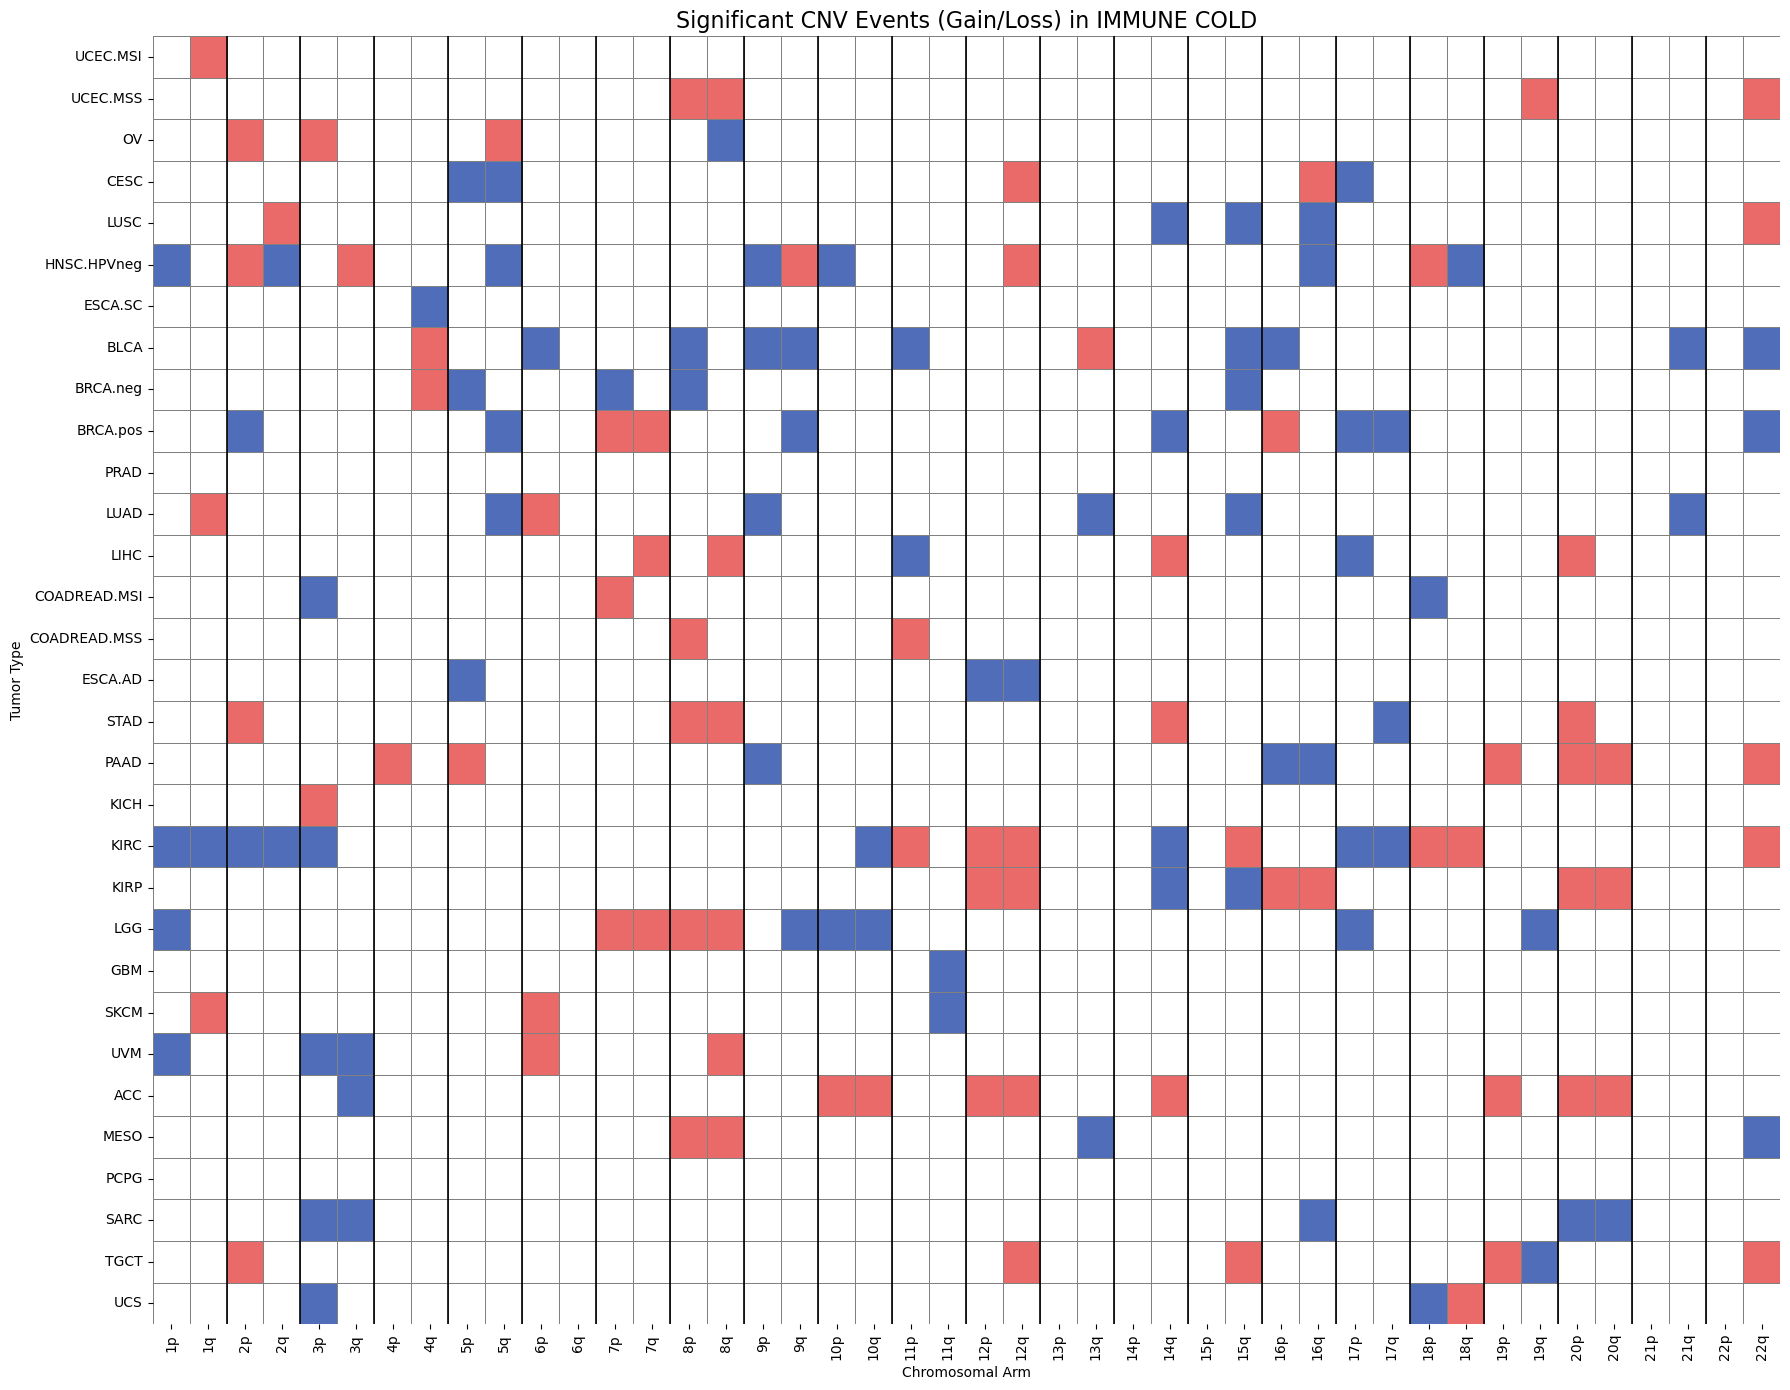

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define ordered tumor types (your specified order)
tumor_types_ordered = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA.neg", "BRCA.pos", "PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD", "STAD", "PAAD", 
    "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "SARC", "TGCT", "UCS"
]

# Define ordered arms (1p–22q)
arms_ordered = [f"{i}{arm}" for i in range(1, 23) for arm in ["p", "q"]]

# Initialize empty dataframe
heatmap_df = pd.DataFrame(0, index=tumor_types_ordered, columns=arms_ordered)

# Fill in heatmap: +1 for Gain, -1 for Loss
for _, row in unique_events.iterrows():
    tumor = row["TumorType"]
    arm = row["Arm"]
    if tumor in tumor_types_ordered and arm in arms_ordered:
        heatmap_df.at[tumor, arm] = 1 if row["Event"] == "Gain" else -1

plt.figure(figsize=(18, 14))

plt.figure(figsize=(18, 14))

# Keep horizontal gridlines by setting linewidths on Y-axis only
sns.heatmap(
    heatmap_df.replace(0, float("nan")),
    cmap=sns.color_palette(["#4F6DB8", "#B8B8B8", "#EA6A6A"]),
    cbar=False,
    linewidths=0.5,       # Keep horizontal lines
    linecolor='gray',
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Significant CNV Events (Gain/Loss) in IMMUNE COLD", fontsize=16)
plt.xlabel("Chromosomal Arm")
plt.ylabel("Tumor Type")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Add vertical separator lines only between chromosomes (not between p and q)
chromosome_breaks = []
last_chr = None
for i, arm in enumerate(arms_ordered):
    chr_num = ''.join(filter(str.isdigit, arm))  # get numeric part of "1p", "1q"
    if chr_num != last_chr:
        chromosome_breaks.append(i)
        last_chr = chr_num

# Add custom vertical lines (not affecting horizontal ones)
for x in chromosome_breaks[1:]:
    plt.axvline(x=x, color="black", linewidth=1.2)

plt.tight_layout()
plt.show()

In [70]:
print("Hot Gain (Arm x TumorType):", hot_gain.shape[0])
print("Hot Loss (Arm x TumorType):", hot_loss.shape[0])

Hot Gain (Arm x TumorType): 49
Hot Loss (Arm x TumorType): 46


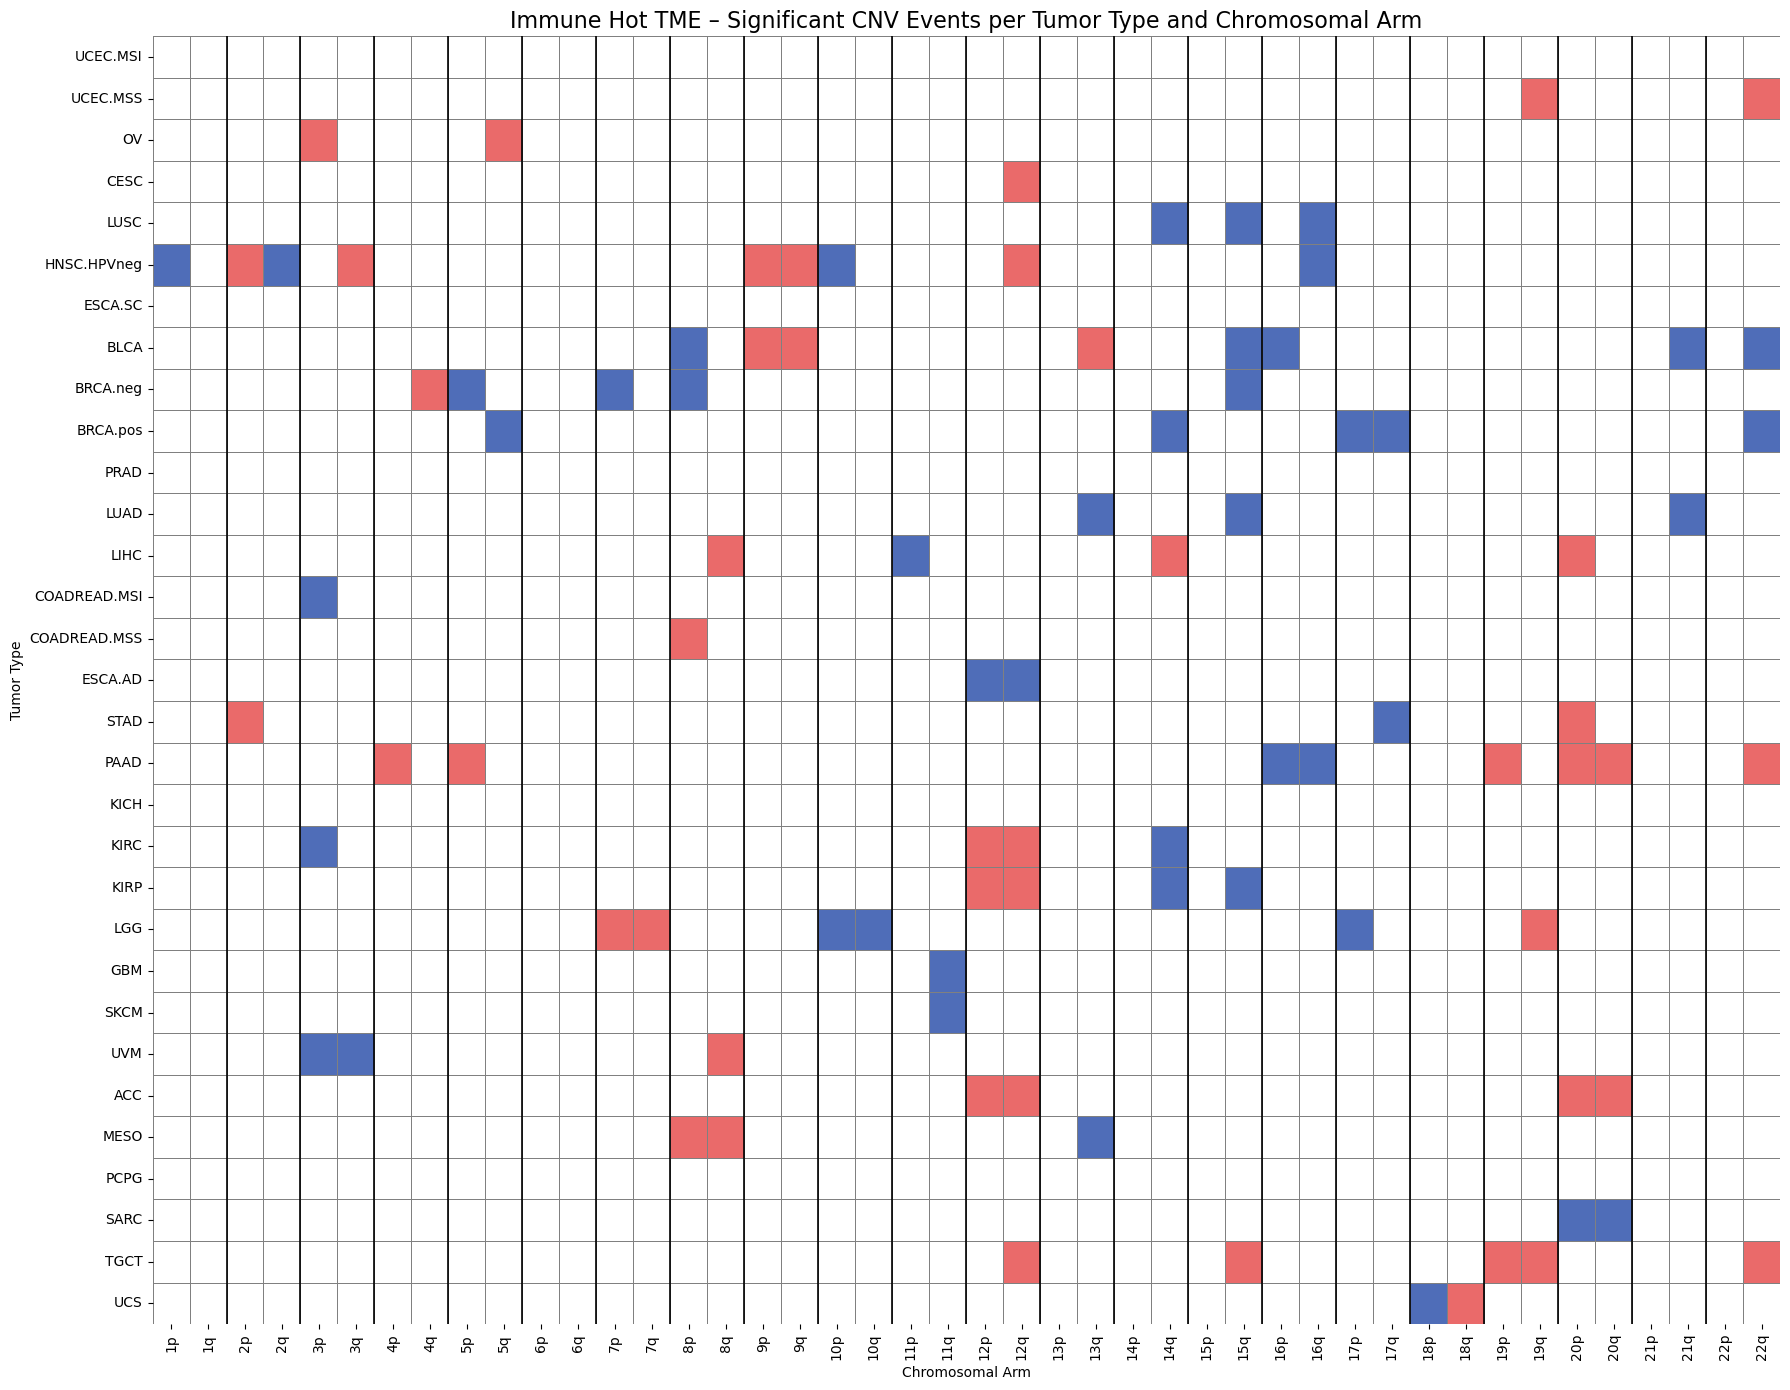

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ordered tumor types (same as manuscript)
tumor_types_ordered = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA.neg", "BRCA.pos", "PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD", "STAD", "PAAD", 
    "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "SARC", "TGCT", "UCS"
]

# Chromosomal arms (1p–22q)
arms_ordered = [f"{i}{arm}" for i in range(1, 23) for arm in ["p", "q"]]

# Build heatmap matrix for immune hot CNV events
heatmap_df = pd.DataFrame(0, index=tumor_types_ordered, columns=arms_ordered)

# Fill matrix with immune hot significant CNV events only
for _, row in hot_sign.iterrows():  # make sure `hot_sign` contains only hot CNV events
    tumor = row["TumorType"]
    arm = row["Arm"]
    if tumor in tumor_types_ordered and arm in arms_ordered:
        heatmap_df.at[tumor, arm] = 1 if row["Event"] == "Gain" else -1

# Plot heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    heatmap_df.replace(0, float("nan")),
    cmap=sns.color_palette(["#4F6DB8", "#B8B8B8", "#EA6A6A"]),  # Blue = Loss, Red = Gain
    cbar=False,
    linewidths=0.5,         # Horizontal gridlines only
    linecolor='gray',
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Immune Hot TME – Significant CNV Events per Tumor Type and Chromosomal Arm", fontsize=16)
plt.xlabel("Chromosomal Arm")
plt.ylabel("Tumor Type")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Draw vertical lines between chromosomes (not between p/q)
chromosome_breaks = []
last_chr = None
for i, arm in enumerate(arms_ordered):
    chr_num = ''.join(filter(str.isdigit, arm))
    if chr_num != last_chr:
        chromosome_breaks.append(i)
        last_chr = chr_num

for x in chromosome_breaks[1:]:
    plt.axvline(x=x, color="black", linewidth=1.2)

plt.tight_layout()
plt.show()

In [73]:
def count_tumor_arm_specificity_corrected(df, label):
    # Create table of (Arm, TumorType) pairs
    combo_df = df[["Arm", "TumorType"]].drop_duplicates()

    # Count number of tumor types each arm appears in
    tumor_counts_per_arm = combo_df.groupby("Arm")["TumorType"].nunique()

    # Add this count info back to the combo_df
    combo_df["NumTumorTypes"] = combo_df["Arm"].map(tumor_counts_per_arm)

    # Now classify (TumorType, Arm) pairs
    only_one_tumor = (combo_df["NumTumorTypes"] == 1).sum()
    more_than_one_tumor = (combo_df["NumTumorTypes"] > 1).sum()

    print(f"{label}:")
    print(f"  Total (TumorType, Arm) pairs: {combo_df.shape[0]}")
    print(f"  Pairs in which Arm occurs in only 1 tumor type: {only_one_tumor}")
    print(f"  Pairs in which Arm occurs in >1 tumor type: {more_than_one_tumor}")
    print()

# Apply to each subset
count_tumor_arm_specificity_corrected(cold_gain, "Cold Gain")
count_tumor_arm_specificity_corrected(cold_loss, "Cold Loss")
count_tumor_arm_specificity_corrected(hot_gain, "Hot Gain")
count_tumor_arm_specificity_corrected(hot_loss, "Hot Loss")

Cold Gain:
  Total (TumorType, Arm) pairs: 42
  Pairs in which Arm occurs in only 1 tumor type: 10
  Pairs in which Arm occurs in >1 tumor type: 32

Cold Loss:
  Total (TumorType, Arm) pairs: 38
  Pairs in which Arm occurs in only 1 tumor type: 12
  Pairs in which Arm occurs in >1 tumor type: 26

Hot Gain:
  Total (TumorType, Arm) pairs: 49
  Pairs in which Arm occurs in only 1 tumor type: 13
  Pairs in which Arm occurs in >1 tumor type: 36

Hot Loss:
  Total (TumorType, Arm) pairs: 46
  Pairs in which Arm occurs in only 1 tumor type: 13
  Pairs in which Arm occurs in >1 tumor type: 33



In [74]:
# Group by Arm + Event, count number of unique tumor types per event for ImmuneCold
cold_counts = signif_df_flag[signif_df_flag["ImmuneCold"] == True] \
    .groupby(["Arm", "Event"])["TumorType"].nunique().reset_index(name="TumorTypeCount")

cold_loss_single = cold_counts[(cold_counts["Event"] == "Loss") & (cold_counts["TumorTypeCount"] == 1)].shape[0]
cold_gain_single = cold_counts[(cold_counts["Event"] == "Gain") & (cold_counts["TumorTypeCount"] == 1)].shape[0]

# Repeat for ImmuneHot
hot_counts = signif_df_flag[signif_df_flag["ImmuneHot"] == True] \
    .groupby(["Arm", "Event"])["TumorType"].nunique().reset_index(name="TumorTypeCount")

hot_loss_single = hot_counts[(hot_counts["Event"] == "Loss") & (hot_counts["TumorTypeCount"] == 1)].shape[0]
hot_gain_single = hot_counts[(hot_counts["Event"] == "Gain") & (hot_counts["TumorTypeCount"] == 1)].shape[0]

cold_loss_single, cold_gain_single, hot_loss_single, hot_gain_single

(13, 11, 14, 13)

In [84]:
# Step 1: Group by Arm, Event, ImmuneCold and count unique tumor types
arm_counts = filtered_df.groupby(["Arm", "Event", "ImmuneCold"])["TumorType"].nunique().reset_index(name="NumTumorTypes")

# Step 2: Filter for arms appearing in 3 or more tumor types
arm_counts_filtered = arm_counts[arm_counts["NumTumorTypes"] >= 3]

# Step 3: Get arms for each category
cold_gain_arms = arm_counts_filtered[
    (arm_counts_filtered["Event"] == "Gain") & (arm_counts_filtered["ImmuneCold"] == True)
]["Arm"].unique().tolist()

cold_loss_arms = arm_counts_filtered[
    (arm_counts_filtered["Event"] == "Loss") & (arm_counts_filtered["ImmuneCold"] == True)
]["Arm"].unique().tolist()

hot_gain_arms = arm_counts_filtered[
    (arm_counts_filtered["Event"] == "Gain") & (arm_counts_filtered["ImmuneCold"] == False)
]["Arm"].unique().tolist()

hot_loss_arms = arm_counts_filtered[
    (arm_counts_filtered["Event"] == "Loss") & (arm_counts_filtered["ImmuneCold"] == False)
]["Arm"].unique().tolist()

# Step 4: Print them for manuscript insertion
print("Arm SCNAs (Gain) associated with LOW IS (Immune Cold) in ≥3 tumor types:")
print(", ".join(sorted(cold_gain_arms)), "\n")

print("Arm SCNAs (Loss) associated with LOW IS (Immune Cold) in ≥3 tumor types:")
print(", ".join(sorted(cold_loss_arms)), "\n")

print("Arm SCNAs (Gain) associated with HIGH IS (Immune Hot) in ≥3 tumor types:")
print(", ".join(sorted(hot_gain_arms)), "\n")

print("Arm SCNAs (Loss) associated with HIGH IS (Immune Hot) in ≥3 tumor types:")
print(", ".join(sorted(hot_loss_arms)), "\n")

Arm SCNAs (Gain) associated with LOW IS (Immune Cold) in ≥3 tumor types:
1q, 6p, 8p, 8q 

Arm SCNAs (Loss) associated with LOW IS (Immune Cold) in ≥3 tumor types:
17p, 1p, 5q, 9p, 9q, Xq 

Arm SCNAs (Gain) associated with HIGH IS (Immune Hot) in ≥3 tumor types:
12p, 12q, 19q, 20p, 20q, 22q, 8q 

Arm SCNAs (Loss) associated with HIGH IS (Immune Hot) in ≥3 tumor types:
14q, 15q, 16q, 3p 



In [93]:
import pandas as pd

# Load the file
top_arms = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Arm_Hits/Continuous_Top_Arms_table.csv")

# Tumor types used in the figure
tumor_types_in_figure = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA.neg", "BRCA.pos", "PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD", "STAD", "PAAD", 
    "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "UCS", "SARC", "TGCT"
]

# Filter only the tumor types shown in the figure and exclude X chromosome
filtered_df = top_arms[
    (top_arms["TumorType"].isin(tumor_types_in_figure)) &
    #(~top_arms["Arm"].str.startswith("X")) &
    (top_arms["AllHits"].notna())
]

# Define a function to compute the tumor specificity
def count_arm_stats_allhits(df, label):
    total_events = df.shape[0]
    combo_df = df[["Arm", "TumorType"]].drop_duplicates()

    tumor_counts_per_arm = combo_df.groupby("Arm")["TumorType"].nunique()
    only_one_tumor = (tumor_counts_per_arm == 1).sum()

    print(f"{label}:")
    print(f"  Total significant Arm x TumorType pairs: {total_events}")
    print(f"  Arms scoring in only one tumor type: {only_one_tumor}")
    print()

# Subset based on AllHits labels
cold_loss_df = filtered_df[filtered_df["AllHits"] == "Loss_ImmuneCold"]
cold_gain_df = filtered_df[filtered_df["AllHits"] == "Gain_ImmuneCold"]
hot_loss_df  = filtered_df[filtered_df["AllHits"] == "Loss_ImmuneHot"]
hot_gain_df  = filtered_df[filtered_df["AllHits"] == "Gain_ImmuneHot"]

# Count and print
count_arm_stats_allhits(cold_loss_df, "Cold Loss")
count_arm_stats_allhits(cold_gain_df, "Cold Gain")
count_arm_stats_allhits(hot_loss_df,  "Hot Loss")
count_arm_stats_allhits(hot_gain_df,  "Hot Gain")

Cold Loss:
  Total significant Arm x TumorType pairs: 35
  Arms scoring in only one tumor type: 11

Cold Gain:
  Total significant Arm x TumorType pairs: 37
  Arms scoring in only one tumor type: 10

Hot Loss:
  Total significant Arm x TumorType pairs: 35
  Arms scoring in only one tumor type: 12

Hot Gain:
  Total significant Arm x TumorType pairs: 41
  Arms scoring in only one tumor type: 9



In [2]:
import pandas as pd

# Load file
arm_df = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Arm_Hits/Continuous_Top_Arms_table.csv")

# Tumor type to tumor group mapping
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Gyn",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "BLCA": "NC-Derived", "BRCA.neg": "NC-Derived", "BRCA.pos": "NC-Derived", "PRAD": "NC-Derived",
    "GBM": "NC-Derived", "LGG": "NC-Derived", "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Adeno", "MESO": "Adeno",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}

# Apply tumor group to DataFrame
arm_df["TumorGroup"] = arm_df["TumorType"].map(tumor_group_map)

# Filter valid tumor types and AllHits entries
tumor_types_in_figure = list(tumor_group_map.keys())
arm_df = arm_df[
    (arm_df["TumorType"].isin(tumor_types_in_figure)) &
    (arm_df["AllHits"].notna())
]

# Count number of events per (TumorGroup x AllHits)
event_counts = arm_df.groupby(["TumorGroup", "AllHits"]).size().unstack(fill_value=0)

# Add totals: total across AllHits (row-wise) and across groups (col-wise)
event_counts["TotalEvents_perGroup"] = event_counts.sum(axis=1)
event_counts.loc["TotalEvents_perHitType"] = event_counts.sum(axis=0)

# Display
print(event_counts)

AllHits                 Gain_ImmuneCold  Gain_ImmuneHot  Loss_ImmuneCold  \
TumorGroup                                                                 
Adeno                                 6               9                5   
GI                                    6               9                3   
Gyn                                   4               2                3   
Kidney                                9               4                3   
NC-Derived                            8               7               12   
Other                                 1               5                5   
Squamous                              3               5                4   
TotalEvents_perHitType               37              41               35   

AllHits                 Loss_ImmuneHot  TotalEvents_perGroup  
TumorGroup                                                    
Adeno                                5                    25  
GI                                   6            

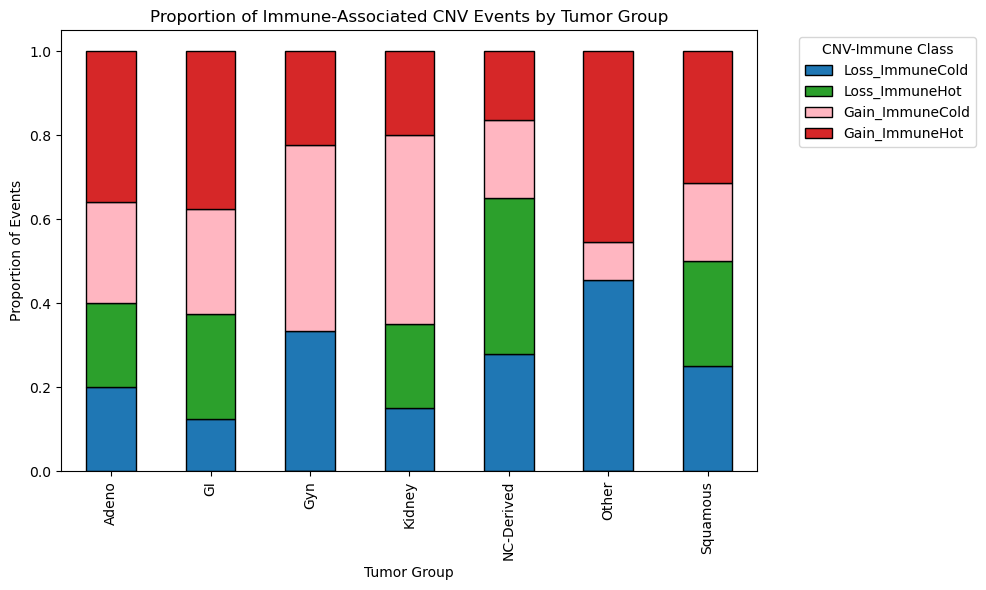

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and preprocess
arm_df = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Arm_Hits/Continuous_Top_Arms_table.csv")

# TumorType → TumorGroup mapping
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Gyn",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "BLCA": "NC-Derived", "BRCA.neg": "NC-Derived", "BRCA.pos": "NC-Derived", "PRAD": "NC-Derived",
    "GBM": "NC-Derived", "LGG": "NC-Derived", "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Adeno", "MESO": "Adeno",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}

# Apply group labels
arm_df["TumorGroup"] = arm_df["TumorType"].map(tumor_group_map)

# Filter to only valid rows
arm_df = arm_df[
    (arm_df["TumorType"].isin(tumor_group_map.keys())) &
    (arm_df["AllHits"].notna())
]

# Count number of events per TumorGroup x CNV-immune class
event_counts = arm_df.groupby(["TumorGroup", "AllHits"]).size().unstack(fill_value=0)

# Define consistent color mapping
color_map = {
    "Loss_ImmuneCold": "#1f77b4",   # Blue
    "Loss_ImmuneHot": "#2ca02c",    # Green
    "Gain_ImmuneCold": "#FFB6C1",   # Pink
    "Gain_ImmuneHot": "#d62728"     # Red
}

# Reorder columns to match color_map if needed
event_props = event_props[[col for col in color_map if col in event_props.columns]]

# Plot with specified colors
event_props.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    edgecolor='black',
    color=[color_map[col] for col in event_props.columns]
)

plt.title("Proportion of Immune-Associated CNV Events by Tumor Group")
plt.xlabel("Tumor Group")
plt.ylabel("Proportion of Events")
plt.legend(title="CNV-Immune Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

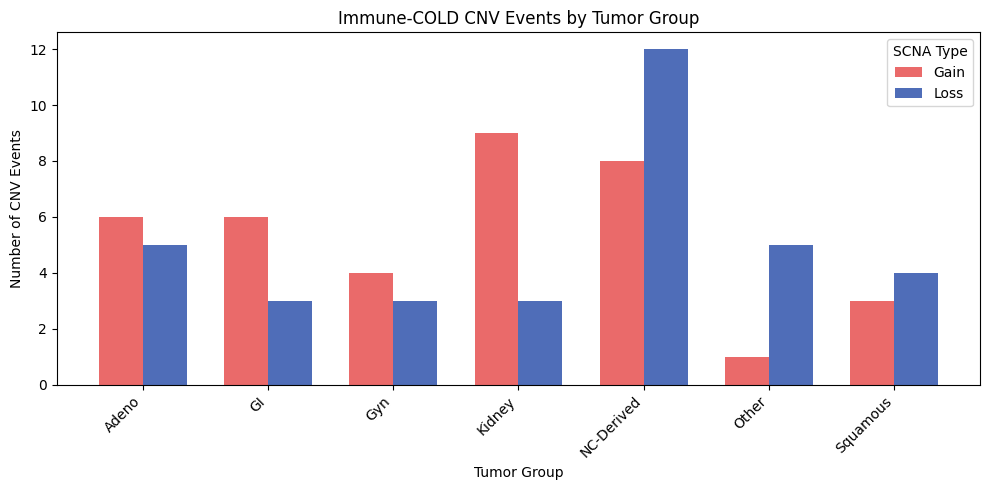

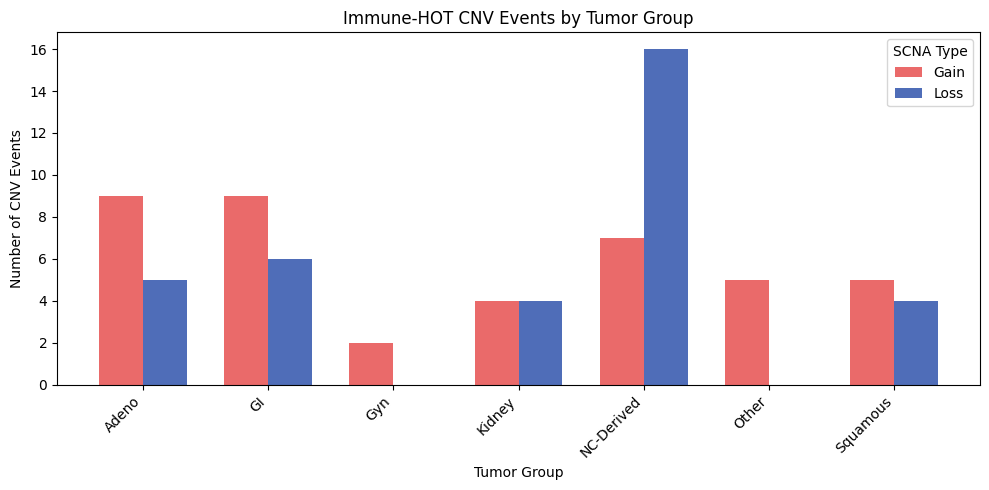

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
arm_df = pd.read_csv(
    "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Arm_Hits/Continuous_Top_Arms_table.csv"
)

# TumorType → TumorGroup mapping
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Gyn",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "BLCA": "NC-Derived", "BRCA.neg": "NC-Derived", "BRCA.pos": "NC-Derived",
    "PRAD": "NC-Derived", "GBM": "NC-Derived", "LGG": "NC-Derived",
    "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Adeno", "MESO": "Adeno",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}
arm_df["TumorGroup"] = arm_df["TumorType"].map(tumor_group_map)

arm_df = arm_df[
    arm_df["TumorType"].isin(tumor_group_map) &
    arm_df["AllHits"].notna()
]

# ── 2. COUNT EVENTS ───────────────────────────────────────────────────────────
event_counts = arm_df.groupby(["TumorGroup", "AllHits"]).size().unstack(fill_value=0)
for col in ["Gain_ImmuneCold", "Loss_ImmuneCold", "Gain_ImmuneHot", "Loss_ImmuneHot"]:
    event_counts[col] = event_counts.get(col, 0)

tumor_groups = ["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"]
immune_cold_df = event_counts[["Gain_ImmuneCold", "Loss_ImmuneCold"]].reindex(tumor_groups)
immune_hot_df  = event_counts[["Gain_ImmuneHot",  "Loss_ImmuneHot"]].reindex(tumor_groups)

# ── 3. PLOT FUNCTION ──────────────────────────────────────────────────────────
def plot_immune_bar(data, title, pdf=None):
    x = np.arange(len(data))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, data.iloc[:, 0], width, label="Gain", color="#EA6A6A")
    ax.bar(x + width/2, data.iloc[:, 1], width, label="Loss", color="#4F6DB8")
    ax.set_title(title)
    ax.set_xlabel("Tumor Group")
    ax.set_ylabel("Number of CNV Events")
    ax.set_xticks(x)
    ax.set_xticklabels(data.index, rotation=45, ha="right")
    ax.legend(title="SCNA Type")
    plt.tight_layout()
    if pdf is not None:
        pdf.savefig(fig)
    plt.show()


# ── 4. SHOW PLOTS ─────────────────────────────────────────────────────────────
plot_immune_bar(immune_cold_df, "Immune-COLD CNV Events by Tumor Group")
plot_immune_bar(immune_hot_df,  "Immune-HOT CNV Events by Tumor Group")


# ── 5. SAVE BOTH FIGURES TO ONEx PDF ───────────────────────────────────────────
# output_path = os.path.join(os.getcwd(), "immune_cnv_events.pdf")
# with PdfPages(output_path) as pdf:
    #plot_immune_bar(immune_cold_df, "Immune-COLD CNV Events by Tumor Group", pdf=pdf)
    #plot_immune_bar(immune_hot_df,  "Immune-HOT CNV Events by Tumor Group",  pdf=pdf)

#print(f"PDF saved to: {output_path}")

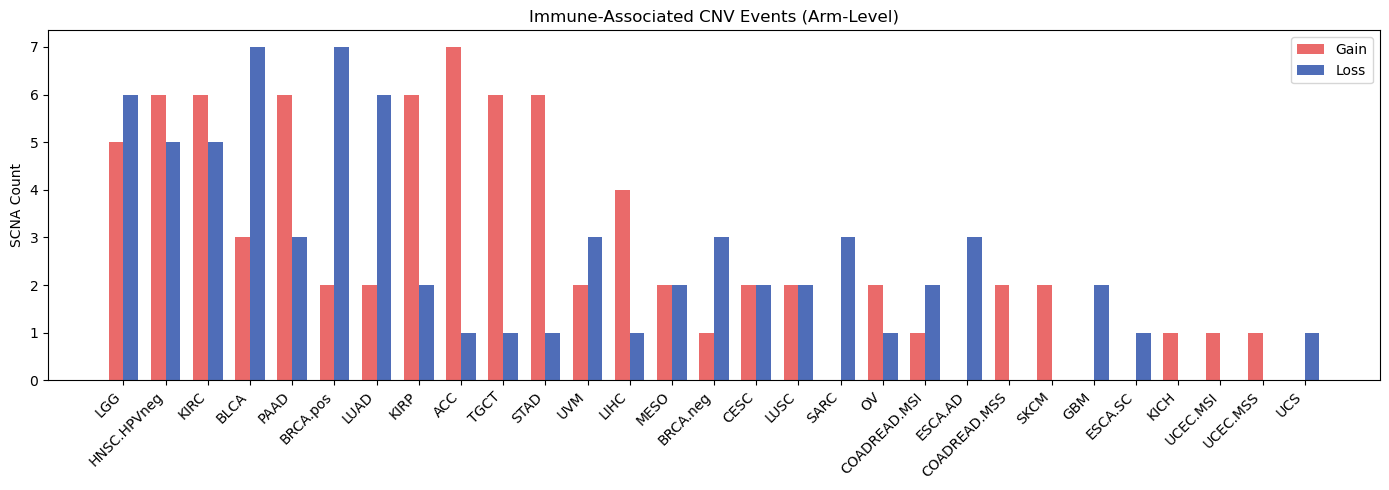

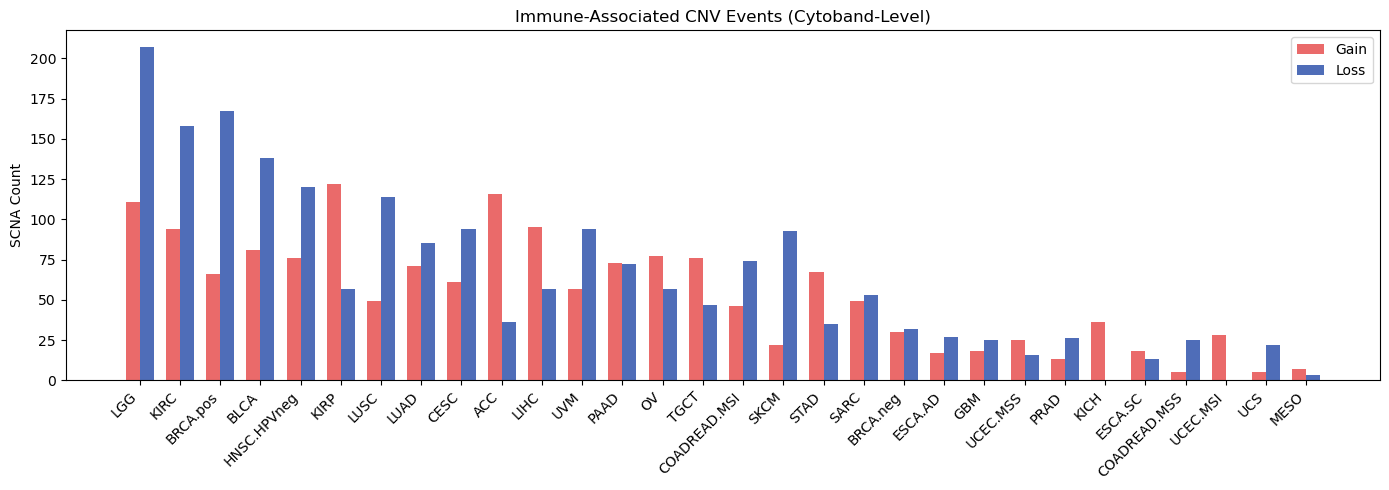

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. LOAD CYTOBAND + ARM DATA ───────────────────────────────────────────────
cyto_df = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")
arm_df  = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Arm_Hits/Continuous_Top_Arms_table.csv")

# ── 2. FILTER AND LABEL ───────────────────────────────────────────────────────
valid_events = ["Gain_ImmuneCold", "Loss_ImmuneCold", "Gain_ImmuneHot", "Loss_ImmuneHot"]

cyto_df = cyto_df[cyto_df["TumorType"].notna() & cyto_df["AllHits"].isin(valid_events)]
arm_df  = arm_df[arm_df["TumorType"].notna()  & arm_df["AllHits"].isin(valid_events)]

cyto_df["Level"] = "Cytoband"
arm_df["Level"] = "Arm"

cyto_df["SCNA_Type"] = cyto_df["AllHits"].apply(lambda x: "Gain" if "Gain" in x else "Loss")
arm_df["SCNA_Type"]  = arm_df["AllHits"].apply(lambda x: "Gain" if "Gain" in x else "Loss")

# ── 3. COUNT SCNAs ────────────────────────────────────────────────────────────
def get_count_df(df, level_name):
    count_df = df.groupby(["TumorType", "SCNA_Type"]).size().unstack(fill_value=0).reset_index()
    count_df["Total"] = count_df["Gain"] + count_df["Loss"]
    count_df["Level"] = level_name
    return count_df.sort_values("Total", ascending=False)

arm_plot  = get_count_df(arm_df, "Arm")
cyto_plot = get_count_df(cyto_df, "Cytoband")

# ── 4. PLOT SEPARATE FIGURES ──────────────────────────────────────────────────
def plot_bar(df, title, filename):
    x = np.arange(len(df))
    width = 0.35
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, df["Gain"], width, label="Gain", color="#EA6A6A")
    ax.bar(x + width/2, df["Loss"], width, label="Loss", color="#4F6DB8")
    ax.set_xticks(x)
    ax.set_xticklabels(df["TumorType"], rotation=45, ha="right")
    ax.set_title(title)
    ax.set_ylabel("SCNA Count")
    ax.legend()
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')  # Save first
    plt.show()

plot_bar(arm_plot, "Immune-Associated CNV Events (Arm-Level)", "Immune_CNV_Arm_Level.pdf")
plot_bar(cyto_plot, "Immune-Associated CNV Events (Cytoband-Level)", "Immune_CNV_Cytoband_Level.pdf")

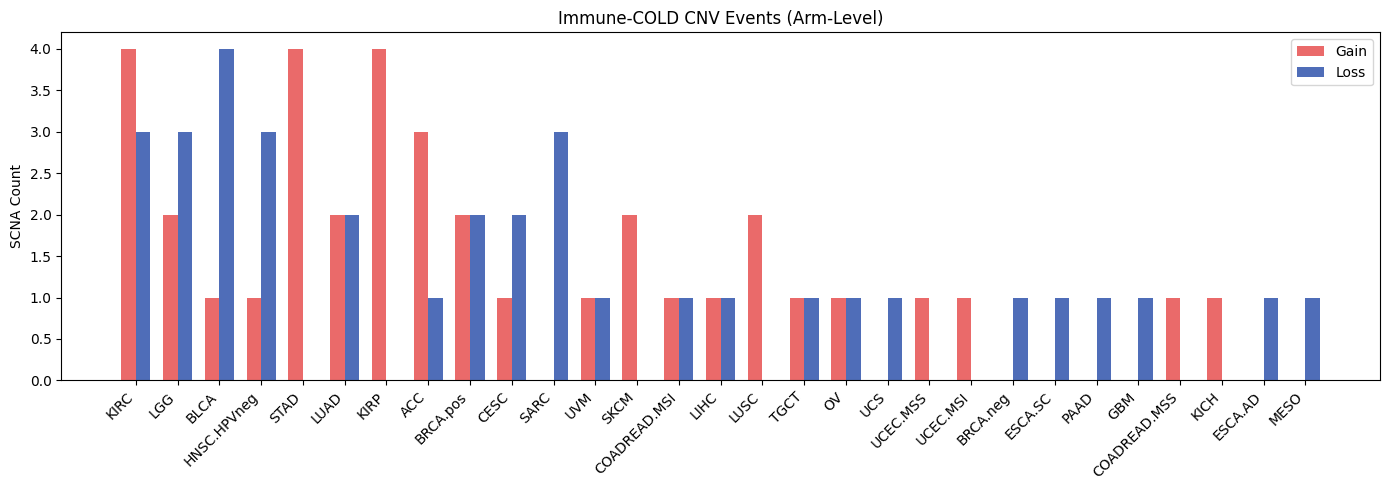

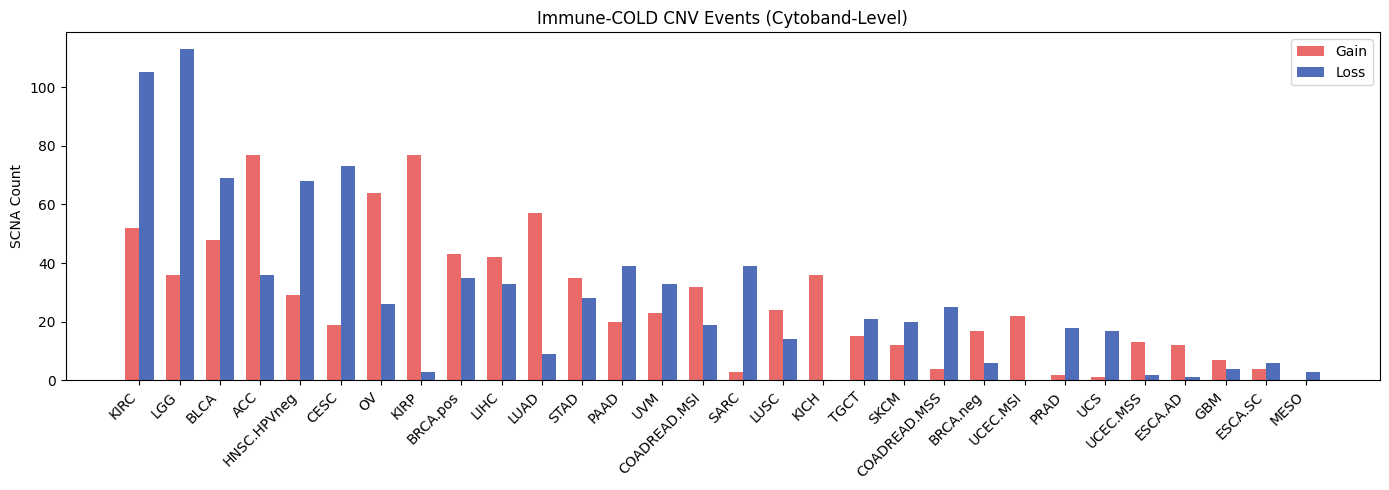

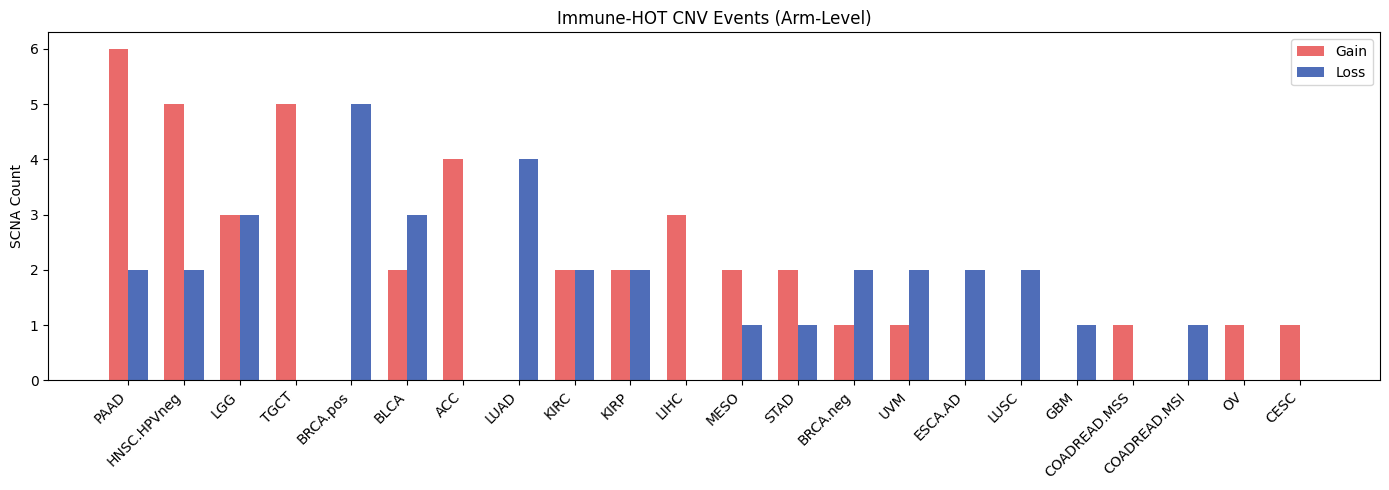

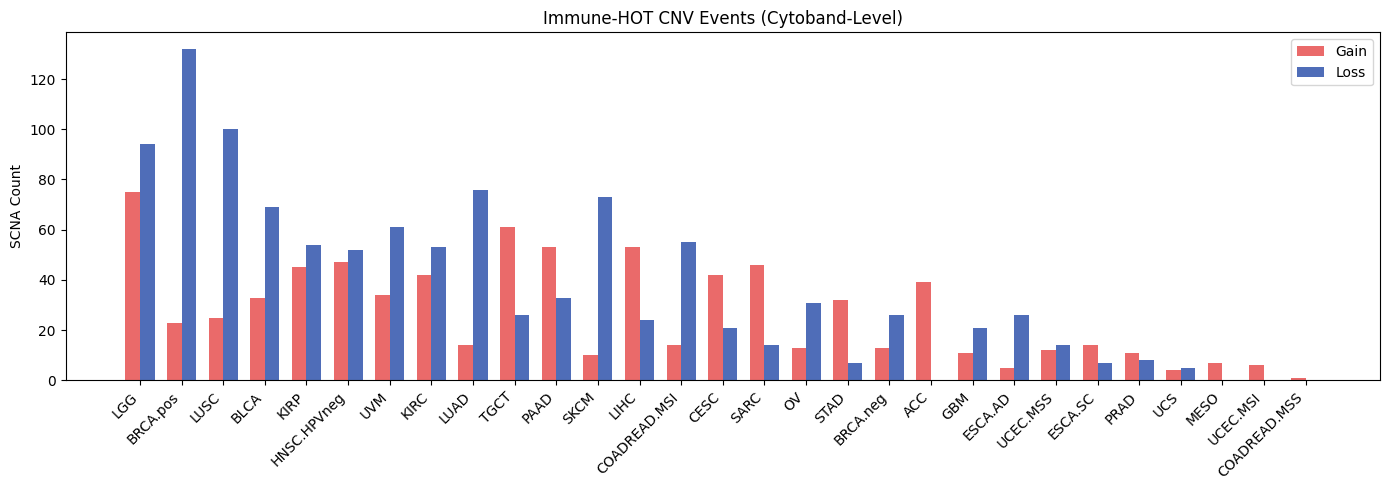

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. LOAD CYTOBAND + ARM DATA ───────────────────────────────────────────────
cyto_df = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")
arm_df  = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Arm_Hits/Continuous_Top_Arms_table.csv")

# ── 2. FILTER FOR IMMUNE-HOT AND IMMUNE-COLD SEPARATELY ───────────────────────
cold_events = ["Gain_ImmuneCold", "Loss_ImmuneCold"]
hot_events  = ["Gain_ImmuneHot", "Loss_ImmuneHot"]

def filter_and_count(df, valid_events, level_name):
    df = df[df["TumorType"].notna() & df["AllHits"].isin(valid_events)].copy()
    df["SCNA_Type"] = df["AllHits"].apply(lambda x: "Gain" if "Gain" in x else "Loss")
    count_df = df.groupby(["TumorType", "SCNA_Type"]).size().unstack(fill_value=0).reset_index()
    count_df["Total"] = count_df["Gain"] + count_df["Loss"]
    count_df["Level"] = level_name
    return count_df.sort_values("Total", ascending=False)

# Cold
arm_cold  = filter_and_count(arm_df, cold_events, "Arm")
cyto_cold = filter_and_count(cyto_df, cold_events, "Cytoband")

# Hot
arm_hot   = filter_and_count(arm_df, hot_events, "Arm")
cyto_hot  = filter_and_count(cyto_df, hot_events, "Cytoband")

# ── 3. PLOT FUNCTION ──────────────────────────────────────────────────────────
def plot_bar(df, title, filename):
    x = np.arange(len(df))
    width = 0.35
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, df["Gain"], width, label="Gain", color="#EA6A6A")
    ax.bar(x + width/2, df["Loss"], width, label="Loss", color="#4F6DB8")
    ax.set_xticks(x)
    ax.set_xticklabels(df["TumorType"], rotation=45, ha="right")
    ax.set_title(title)
    ax.set_ylabel("SCNA Count")
    ax.legend()
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

# ── 4. PLOT AND SAVE ──────────────────────────────────────────────────────────

# Immune-COLD
plot_bar(arm_cold,  "Immune-COLD CNV Events (Arm-Level)",      "ImmuneCold_CNV_Arm_Level.pdf")
plot_bar(cyto_cold, "Immune-COLD CNV Events (Cytoband-Level)", "ImmuneCold_CNV_Cytoband_Level.pdf")

# Immune-HOT
plot_bar(arm_hot,   "Immune-HOT CNV Events (Arm-Level)",       "ImmuneHot_CNV_Arm_Level.pdf")
plot_bar(cyto_hot,  "Immune-HOT CNV Events (Cytoband-Level)",  "ImmuneHot_CNV_Cytoband_Level.pdf")

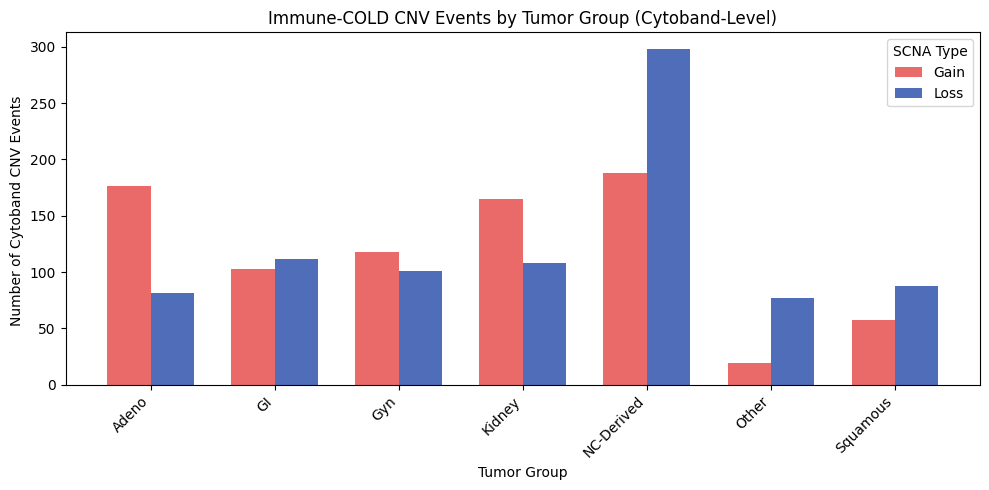

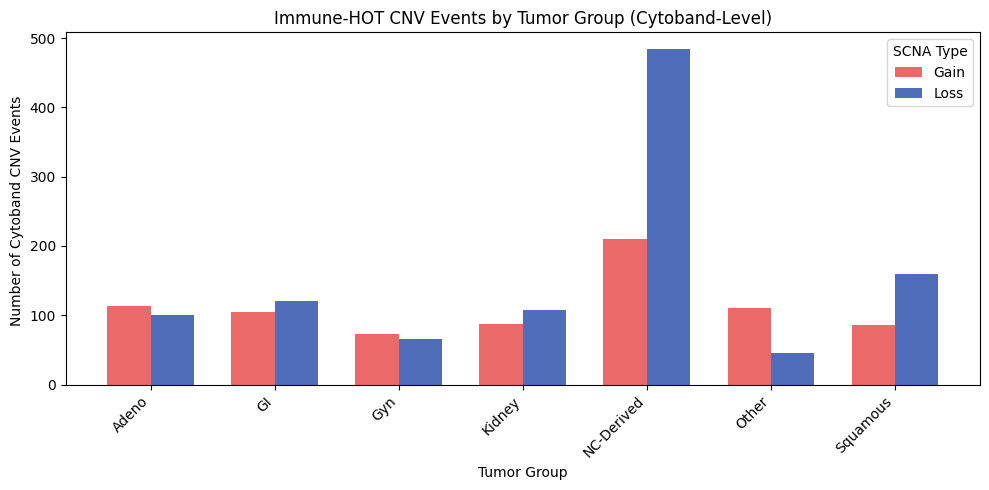

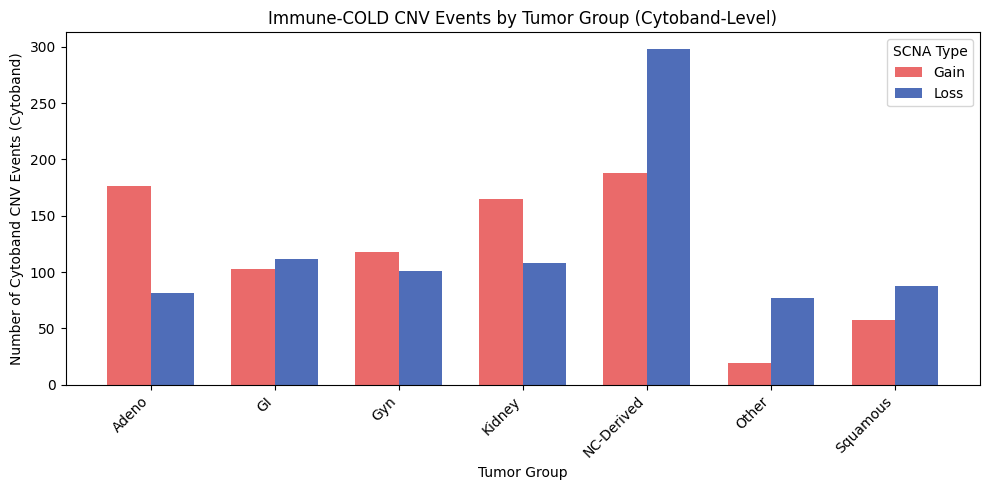

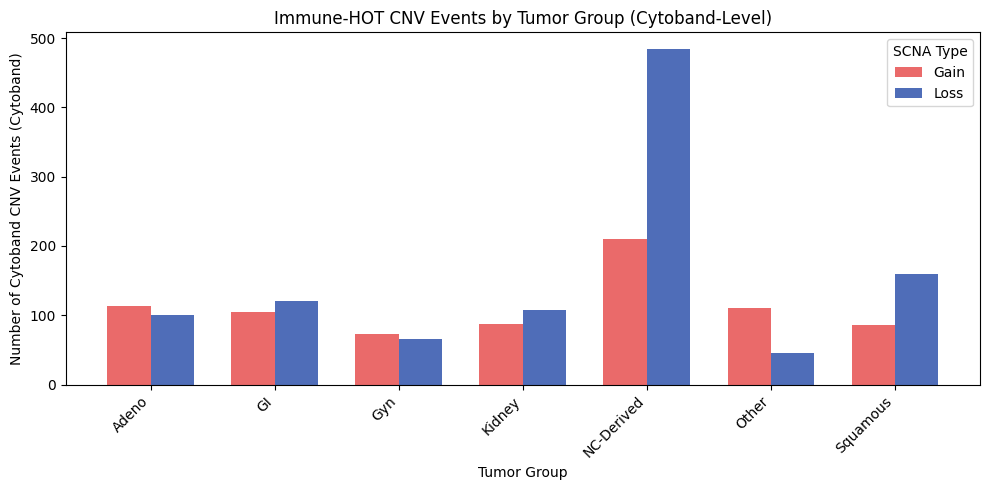

Saved cytoband-level bar plots to: /Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/scores/cytoband_immune_cnv_events.pdf


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. LOAD CYTOBAND-LEVEL DATA ───────────────────────────────────────────────
cyto_df = pd.read_csv(
    "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv"
)

# TumorType → TumorGroup mapping
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Gyn",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "BLCA": "NC-Derived", "BRCA.neg": "NC-Derived", "BRCA.pos": "NC-Derived",
    "PRAD": "NC-Derived", "GBM": "NC-Derived", "LGG": "NC-Derived",
    "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Adeno", "MESO": "Adeno",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}
cyto_df["TumorGroup"] = cyto_df["TumorType"].map(tumor_group_map)

# Filter to valid tumor types and non-null hits
cyto_df = cyto_df[
    cyto_df["TumorType"].isin(tumor_group_map) &
    cyto_df["AllHits"].notna()
]

# ── 2. COUNT CYTOBAND-LEVEL EVENTS ────────────────────────────────────────────
cyto_event_counts = cyto_df.groupby(["TumorGroup", "AllHits"]).size().unstack(fill_value=0)

# Ensure all 4 event types exist
for col in ["Gain_ImmuneCold", "Loss_ImmuneCold", "Gain_ImmuneHot", "Loss_ImmuneHot"]:
    cyto_event_counts[col] = cyto_event_counts.get(col, 0)

tumor_groups = ["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"]
cyto_immune_cold_df = cyto_event_counts[["Gain_ImmuneCold", "Loss_ImmuneCold"]].reindex(tumor_groups)
cyto_immune_hot_df  = cyto_event_counts[["Gain_ImmuneHot",  "Loss_ImmuneHot"]].reindex(tumor_groups)

# ── 3. PLOT FUNCTION ──────────────────────────────────────────────────────────
def plot_immune_bar(data, title, label_suffix="", pdf=None):
    x = np.arange(len(data))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, data.iloc[:, 0], width, label="Gain", color="#EA6A6A")
    ax.bar(x + width/2, data.iloc[:, 1], width, label="Loss", color="#4F6DB8")
    ax.set_title(title)
    ax.set_xlabel("Tumor Group")
    ax.set_ylabel(f"Number of Cytoband CNV Events {label_suffix}")
    ax.set_xticks(x)
    ax.set_xticklabels(data.index, rotation=45, ha="right")
    ax.legend(title="SCNA Type")
    plt.tight_layout()
    if pdf:
        pdf.savefig(fig)
    plt.show()

# ── 4. SHOW CYTOBAND-LEVEL PLOTS ──────────────────────────────────────────────

from matplotlib.backends.backend_pdf import PdfPages

output_path = os.path.join(os.getcwd(), "cytoband_immune_cnv_events.pdf")

with PdfPages(output_path) as pdf:
    plot_immune_bar(cyto_immune_cold_df, 
                    "Immune-COLD CNV Events by Tumor Group (Cytoband-Level)",
                    label_suffix="(Cytoband)", 
                    pdf=pdf)
    
    plot_immune_bar(cyto_immune_hot_df,  
                    "Immune-HOT CNV Events by Tumor Group (Cytoband-Level)",
                    label_suffix="(Cytoband)", 
                    pdf=pdf)

print(f"Saved cytoband-level bar plots to: {output_path}")

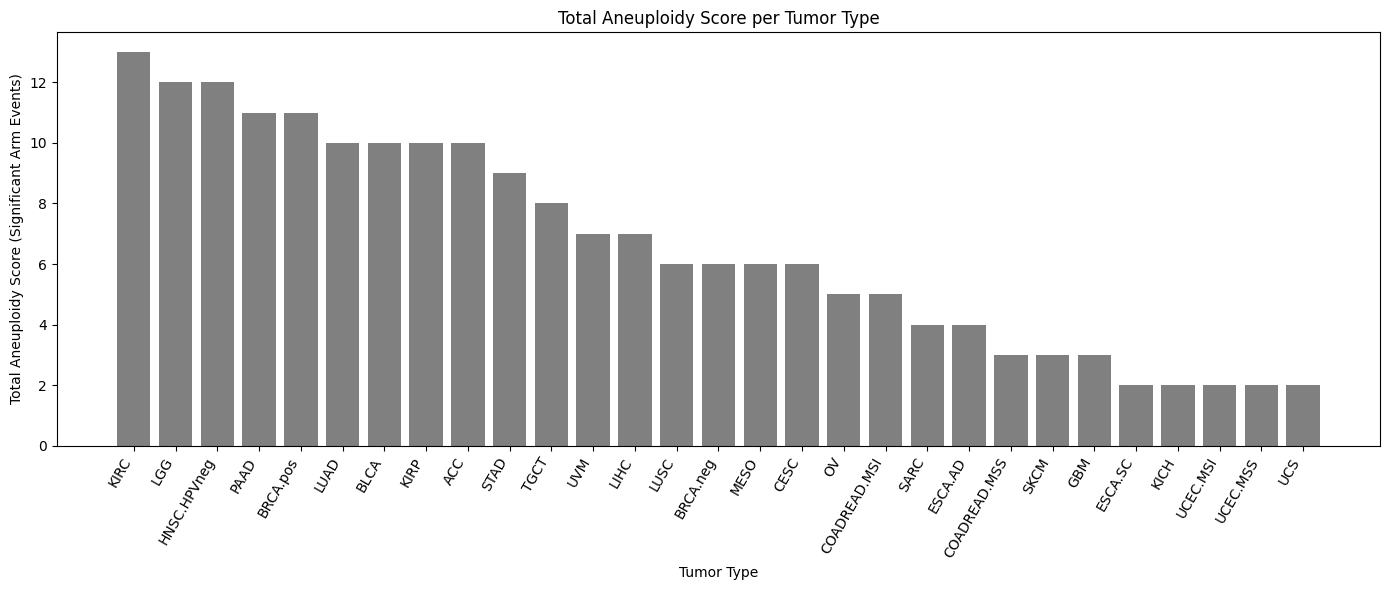

In [4]:
# ── 6. TOTAL ANEUPLOIDY SCORE PER TUMOR TYPE ────────────────────────────────

# Calculate total aneuploidy score per tumor type (number of significant arm-level events)
aneuploidy_score = (
    arm_df.groupby("TumorType")[["Arm", "Event"]]
    .nunique()
    .sum(axis=1)
    .sort_values(ascending=False)
)

# Plot bar plot for each tumor type
plt.figure(figsize=(14, 6))
plt.bar(aneuploidy_score.index, aneuploidy_score.values, color="gray")
plt.title("Total Aneuploidy Score per Tumor Type")
plt.xlabel("Tumor Type")
plt.ylabel("Total Aneuploidy Score (Significant Arm Events)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()

plt.savefig("total_aneuploidy_score_by_tumors.pdf", bbox_inches="tight")

plt.show()

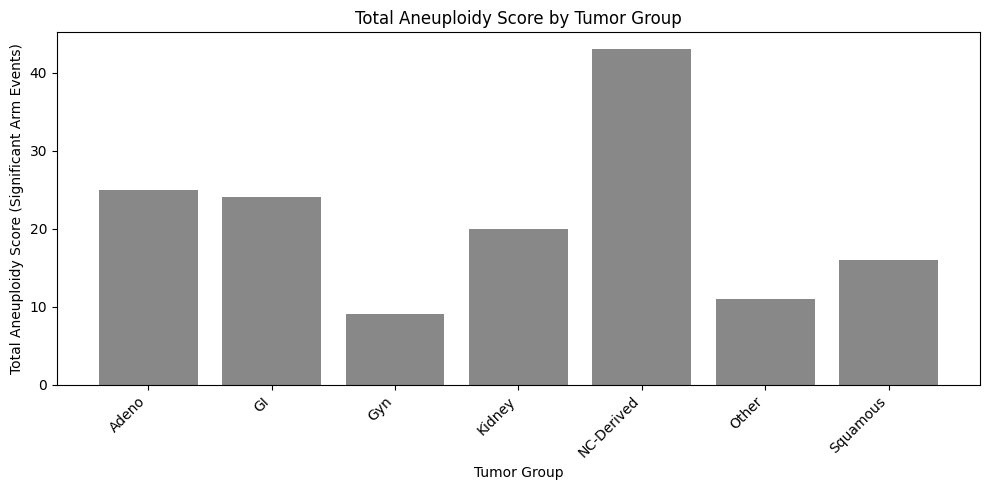

In [5]:
# Calculate total aneuploidy score per Tumor Group (sum of significant arm-level events)
# Each (Arm, Event, TumorType) is a unique event, so count per TumorGroup

# First, count unique (TumorType, Arm, Event) events
unique_events = arm_df.drop_duplicates(subset=["TumorType", "Arm", "Event"])

# Map TumorType to TumorGroup (already in arm_df as 'TumorGroup')
# Group by TumorGroup and count total events
as_by_group = (
    unique_events.groupby("TumorGroup")
    .size()
    .reindex(["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"])
)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(as_by_group.index, as_by_group.values, color="#888888")
plt.title("Total Aneuploidy Score by Tumor Group")
plt.xlabel("Tumor Group")
plt.ylabel("Total Aneuploidy Score (Significant Arm Events)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("total_aneuploidy_score_by_tumor_group.pdf", bbox_inches="tight")

plt.show()

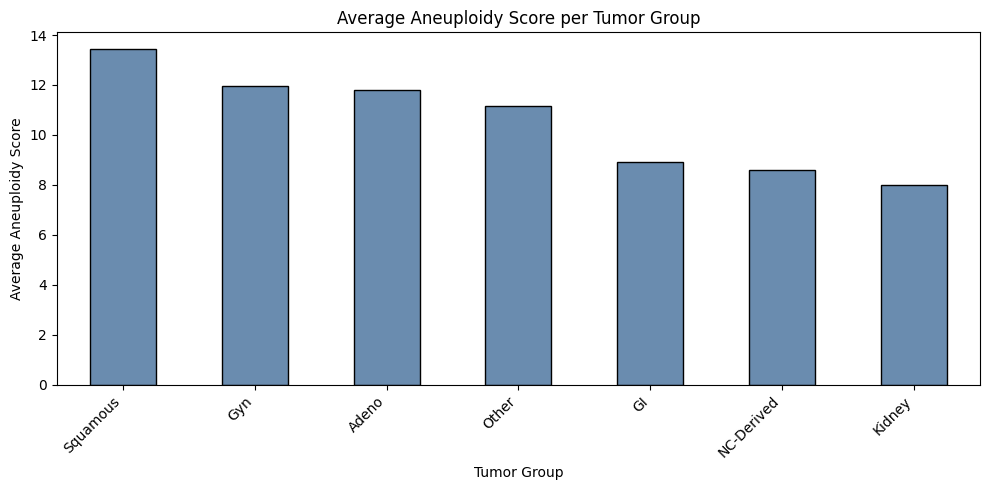

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the aneuploidy score CSV
df = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/All_Tumor_Aneuploidy_Scores.csv")

# Define tumor type → group mapping
tumor_group_map = {
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Adeno", "MESO": "Adeno",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Gyn",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "BLCA": "NC-Derived", "BRCA.neg": "NC-Derived", "BRCA.pos": "NC-Derived", "PRAD": "NC-Derived",
    "GBM": "NC-Derived", "LGG": "NC-Derived", "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}

# Map tumor types to groups
df["TumorGroup"] = df["Tumor_Type"].map(tumor_group_map)

# Drop rows with no group mapping
df = df.dropna(subset=["TumorGroup"])

# Compute average or total aneuploidy score per tumor group
group_as = df.groupby("TumorGroup")["Aneuploidy_Score"].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
group_as.plot(kind="bar", color="#6A8CAF", edgecolor="black")
plt.ylabel("Average Aneuploidy Score")
plt.xlabel("Tumor Group")
plt.title("Average Aneuploidy Score per Tumor Group")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("AneuploidyScore_by_TumorGroup.pdf")
plt.show()

In [3]:
# Filter relevant rows
filtered_df = arm_df[
    (arm_df["TumorType"].isin(tumor_types_in_figure)) &
    (arm_df["AllHits"].notna())
]

# Step 1: Group by Arm and AllHits and count number of unique tumor types
arm_counts = filtered_df.groupby(["Arm", "AllHits"])["TumorType"].nunique().reset_index(name="NumTumorTypes")

# Step 2: Keep only arms with ≥3 tumor types per AllHits event
arm_counts_filtered = arm_counts[arm_counts["NumTumorTypes"] >= 3]

# Step 3: Extract arms per AllHits label
cold_gain_arms = arm_counts_filtered[arm_counts_filtered["AllHits"] == "Gain_ImmuneCold"]["Arm"].unique().tolist()
cold_loss_arms = arm_counts_filtered[arm_counts_filtered["AllHits"] == "Loss_ImmuneCold"]["Arm"].unique().tolist()
hot_gain_arms  = arm_counts_filtered[arm_counts_filtered["AllHits"] == "Gain_ImmuneHot"]["Arm"].unique().tolist()
hot_loss_arms  = arm_counts_filtered[arm_counts_filtered["AllHits"] == "Loss_ImmuneHot"]["Arm"].unique().tolist()

# Step 4: Print for manuscript
print("Arm SCNAs (Gain) associated with LOW IS (Immune Cold) in ≥3 tumor types:")
print(", ".join(sorted(cold_gain_arms)), "\n")

print("Arm SCNAs (Loss) associated with LOW IS (Immune Cold) in ≥3 tumor types:")
print(", ".join(sorted(cold_loss_arms)), "\n")

print("Arm SCNAs (Gain) associated with HIGH IS (Immune Hot) in ≥3 tumor types:")
print(", ".join(sorted(hot_gain_arms)), "\n")

print("Arm SCNAs (Loss) associated with HIGH IS (Immune Hot) in ≥3 tumor types:")
print(", ".join(sorted(hot_loss_arms)), "\n")

Arm SCNAs (Gain) associated with LOW IS (Immune Cold) in ≥3 tumor types:
1q, 6p, 8p 

Arm SCNAs (Loss) associated with LOW IS (Immune Cold) in ≥3 tumor types:
1p, 5q, 9p, 9q, Xq 

Arm SCNAs (Gain) associated with HIGH IS (Immune Hot) in ≥3 tumor types:
12p, 12q, 20p, 8q 

Arm SCNAs (Loss) associated with HIGH IS (Immune Hot) in ≥3 tumor types:
14q, 15q, 16q, 3p 



# Cytobands

In [96]:
import pandas as pd

# Load the cytoband file
cytoband_df = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Tumor types used in the figure
tumor_types_in_figure = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA.neg", "BRCA.pos", "PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD", "STAD", "PAAD", 
    "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "UCS", "SARC", "TGCT"
]

# Filter to tumor types used in the figure and exclude X chromosome cytobands
filtered_df = cytoband_df[
    (cytoband_df["TumorType"].isin(tumor_types_in_figure)) &
    # (~cytoband_df["Cytoband"].str.startswith("X")) &
    (cytoband_df["AllHits"].notna())
]

# Subset by AllHits categories
cold_loss_df = filtered_df[filtered_df["AllHits"] == "Loss_ImmuneCold"]
cold_gain_df = filtered_df[filtered_df["AllHits"] == "Gain_ImmuneCold"]
hot_loss_df  = filtered_df[filtered_df["AllHits"] == "Loss_ImmuneHot"]
hot_gain_df  = filtered_df[filtered_df["AllHits"] == "Gain_ImmuneHot"]

# Print the Cytoband × TumorType counts for each subset
print("Cold Gain (Cytoband x TumorType):", cold_gain_df.shape[0])
print("Cold Loss (Cytoband x TumorType):", cold_loss_df.shape[0])
print("Hot Gain (Cytoband x TumorType):", hot_gain_df.shape[0])
print("Hot Loss (Cytoband x TumorType):", hot_loss_df.shape[0])

Cold Gain (Cytoband x TumorType): 826
Cold Loss (Cytoband x TumorType): 865
Hot Gain (Cytoband x TumorType): 785
Hot Loss (Cytoband x TumorType): 1082


In [95]:
import pandas as pd

# Load the cytoband file
top_cytobands = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Tumor types used in the figure
tumor_types_in_figure = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA.neg", "BRCA.pos", "PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD", "STAD", "PAAD", 
    "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "UCS", "SARC", "TGCT"
]

# Filter only tumor types in figure and AllHits not NA
filtered_df = top_cytobands[
    (top_cytobands["TumorType"].isin(tumor_types_in_figure)) &
    #(~top_cytobands["Cytoband"].str.startswith("X")) &
    (top_cytobands["AllHits"].notna())
]

# Define function for cytoband tumor specificity
def count_cytoband_stats_allhits(df, label):
    total_events = df.shape[0]
    combo_df = df[["Cytoband", "TumorType"]].drop_duplicates()

    tumor_counts_per_cytoband = combo_df.groupby("Cytoband")["TumorType"].nunique()
    only_one_tumor = (tumor_counts_per_cytoband == 1).sum()

    print(f"{label}:")
    print(f"  Total significant Cytoband x TumorType pairs: {total_events}")
    print(f"  Cytobands scoring in only one tumor type: {only_one_tumor}")
    print()

# Subset by AllHits labels
cold_loss_df = filtered_df[filtered_df["AllHits"] == "Loss_ImmuneCold"]
cold_gain_df = filtered_df[filtered_df["AllHits"] == "Gain_ImmuneCold"]
hot_loss_df  = filtered_df[filtered_df["AllHits"] == "Loss_ImmuneHot"]
hot_gain_df  = filtered_df[filtered_df["AllHits"] == "Gain_ImmuneHot"]

# Count and print
count_cytoband_stats_allhits(cold_loss_df, "Cold Loss")
count_cytoband_stats_allhits(cold_gain_df, "Cold Gain")
count_cytoband_stats_allhits(hot_loss_df,  "Hot Loss")
count_cytoband_stats_allhits(hot_gain_df,  "Hot Gain")

Cold Loss:
  Total significant Cytoband x TumorType pairs: 865
  Cytobands scoring in only one tumor type: 239

Cold Gain:
  Total significant Cytoband x TumorType pairs: 826
  Cytobands scoring in only one tumor type: 306

Hot Loss:
  Total significant Cytoband x TumorType pairs: 1082
  Cytobands scoring in only one tumor type: 235

Hot Gain:
  Total significant Cytoband x TumorType pairs: 785
  Cytobands scoring in only one tumor type: 258



In [89]:
def count_cytoband_stats(df, label):
    # Filter to only tumor types in the figure and exclude chrX
    tumor_types_in_figure = [
        "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
        "HNSC.HPVneg", "ESCA.SC", "BLCA", "BRCA.neg", "BRCA.pos", "PRAD",
        "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", "ESCA.AD", "STAD", "PAAD", 
        "KICH", "KIRC", "KIRP", "LGG", "GBM", "SKCM", "UVM", "ACC", "MESO", "PCPG", "UCS", "SARC", "TGCT"
    ]
    df = df[
        df["TumorType"].isin(tumor_types_in_figure) &
        ~df["Cytoband"].str.startswith("X")
    ]

    # Total number of significant cytoband events (raw, no dropping)
    total_events = df.shape[0]

    # Count how many tumor types each cytoband appears in
    cytoband_tumor_map = df.groupby("Cytoband")["TumorType"].apply(list)
    single_tumor_cytobands = cytoband_tumor_map.apply(lambda tumors: len(set(tumors)) == 1).sum()

    print(f"{label}:")
    print(f"  Total significant cytoband events (raw): {total_events}")
    print(f"  Cytobands scoring in only one tumor type: {single_tumor_cytobands}")
    print()

count_cytoband_stats(cold_gain, "Cold Gain")
count_cytoband_stats(cold_loss, "Cold Loss")
count_cytoband_stats(hot_gain,  "Hot Gain")
count_cytoband_stats(hot_loss,  "Hot Loss")

Cold Gain:
  Total significant cytoband events (raw): 947
  Cytobands scoring in only one tumor type: 291

Cold Loss:
  Total significant cytoband events (raw): 906
  Cytobands scoring in only one tumor type: 243

Hot Gain:
  Total significant cytoband events (raw): 843
  Cytobands scoring in only one tumor type: 268

Hot Loss:
  Total significant cytoband events (raw): 1178
  Cytobands scoring in only one tumor type: 219



In [1]:
import pandas as pd

# Load cytoband data
cytoband_df = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Only keep rows with AllHits information (i.e., the 4 event types)
cytoband_df = cytoband_df[cytoband_df["AllHits"].notna()]

# Tumor type to group mapping
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Squamous",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "BLCA": "Squamous", "BRCA.neg": "Adeno", "BRCA.pos": "Adeno", "PRAD": "Adeno",
    "GBM": "NC-Derived", "LGG": "NC-Derived", "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Other", "MESO": "Other",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}

# Add TumorGroup column
cytoband_df["TumorGroup"] = cytoband_df["TumorType"].map(tumor_group_map)

# Filter to tumor types shown in figure
tumor_types_in_figure = list(tumor_group_map.keys())
cytoband_df = cytoband_df[cytoband_df["TumorType"].isin(tumor_types_in_figure)]

# Count 4 event types within each tumor group
event_counts_by_group = cytoband_df.groupby(["TumorGroup", "AllHits"]).size().unstack(fill_value=0)

# Show result
print(event_counts_by_group)

AllHits     Gain_ImmuneCold  Gain_ImmuneHot  Loss_ImmuneCold  Loss_ImmuneHot
TumorGroup                                                                  
Adeno                   161             114              101             266
GI                      103             105              112             121
Gyn                      99              31               28              45
Kidney                  165              87              108             107
NC-Derived               78             130              170             249
Other                    96             157              116              45
Squamous                124             161              230             249


In [4]:
import pandas as pd

# Load cytoband data
cytoband_df = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Filter to only entries with defined AllHits
cytoband_df = cytoband_df[cytoband_df["AllHits"].notna()]

# Tumor type to tumor group mapping
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Gyn",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "BLCA": "NC-Derived", "BRCA.neg": "NC-Derived", "BRCA.pos": "NC-Derived", "PRAD": "NC-Derived",
    "GBM": "NC-Derived", "LGG": "NC-Derived", "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Adeno", "MESO": "Adeno",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}

# Apply tumor group
cytoband_df["TumorGroup"] = cytoband_df["TumorType"].map(tumor_group_map)

# Keep only tumor types in figure
tumor_types_in_figure = list(tumor_group_map.keys())
cytoband_df = cytoband_df[cytoband_df["TumorType"].isin(tumor_types_in_figure)]

# --- PART 1: Count event types by tumor group ---
event_counts = cytoband_df.groupby(["TumorGroup", "AllHits"]).size().unstack(fill_value=0)
event_counts["TotalEvents_perGroup"] = event_counts.sum(axis=1)
event_counts.loc["TotalEvents_perHitType"] = event_counts.sum(axis=0)
print("==== Event Counts by Tumor Group ====")
print(event_counts)
print("\n")

# --- PART 2: Cytobands found in ≥3 tumor types per AllHits type ---
filtered_df = cytoband_df[cytoband_df["AllHits"].notna()]

cytoband_counts = filtered_df.groupby(["Cytoband", "AllHits"])["TumorType"].nunique().reset_index(name="NumTumorTypes")
cytoband_counts_filtered = cytoband_counts[cytoband_counts["NumTumorTypes"] >= 3]

def print_cytobands_by_event(event_label):
    bands = cytoband_counts_filtered[cytoband_counts_filtered["AllHits"] == event_label]["Cytoband"].unique().tolist()
    print(f"{event_label} – Cytobands associated with ≥3 tumor types:")
    print(", ".join(sorted(bands)), "\n")

print("==== Cytobands in ≥3 Tumor Types ====\n")
for event in ["Loss_ImmuneCold", "Gain_ImmuneCold", "Loss_ImmuneHot", "Gain_ImmuneHot"]:
    print_cytobands_by_event(event)

==== Event Counts by Tumor Group ====
AllHits                 Gain_ImmuneCold  Gain_ImmuneHot  Loss_ImmuneCold  \
TumorGroup                                                                 
Adeno                               176             113               81   
GI                                  103             105              112   
Gyn                                 118              73              101   
Kidney                              165              87              108   
NC-Derived                          188             210              298   
Other                                19             111               77   
Squamous                             57              86               88   
TotalEvents_perHitType              826             785              865   

AllHits                 Loss_ImmuneHot  TotalEvents_perGroup  
TumorGroup                                                    
Adeno                              100                   470  
GI          

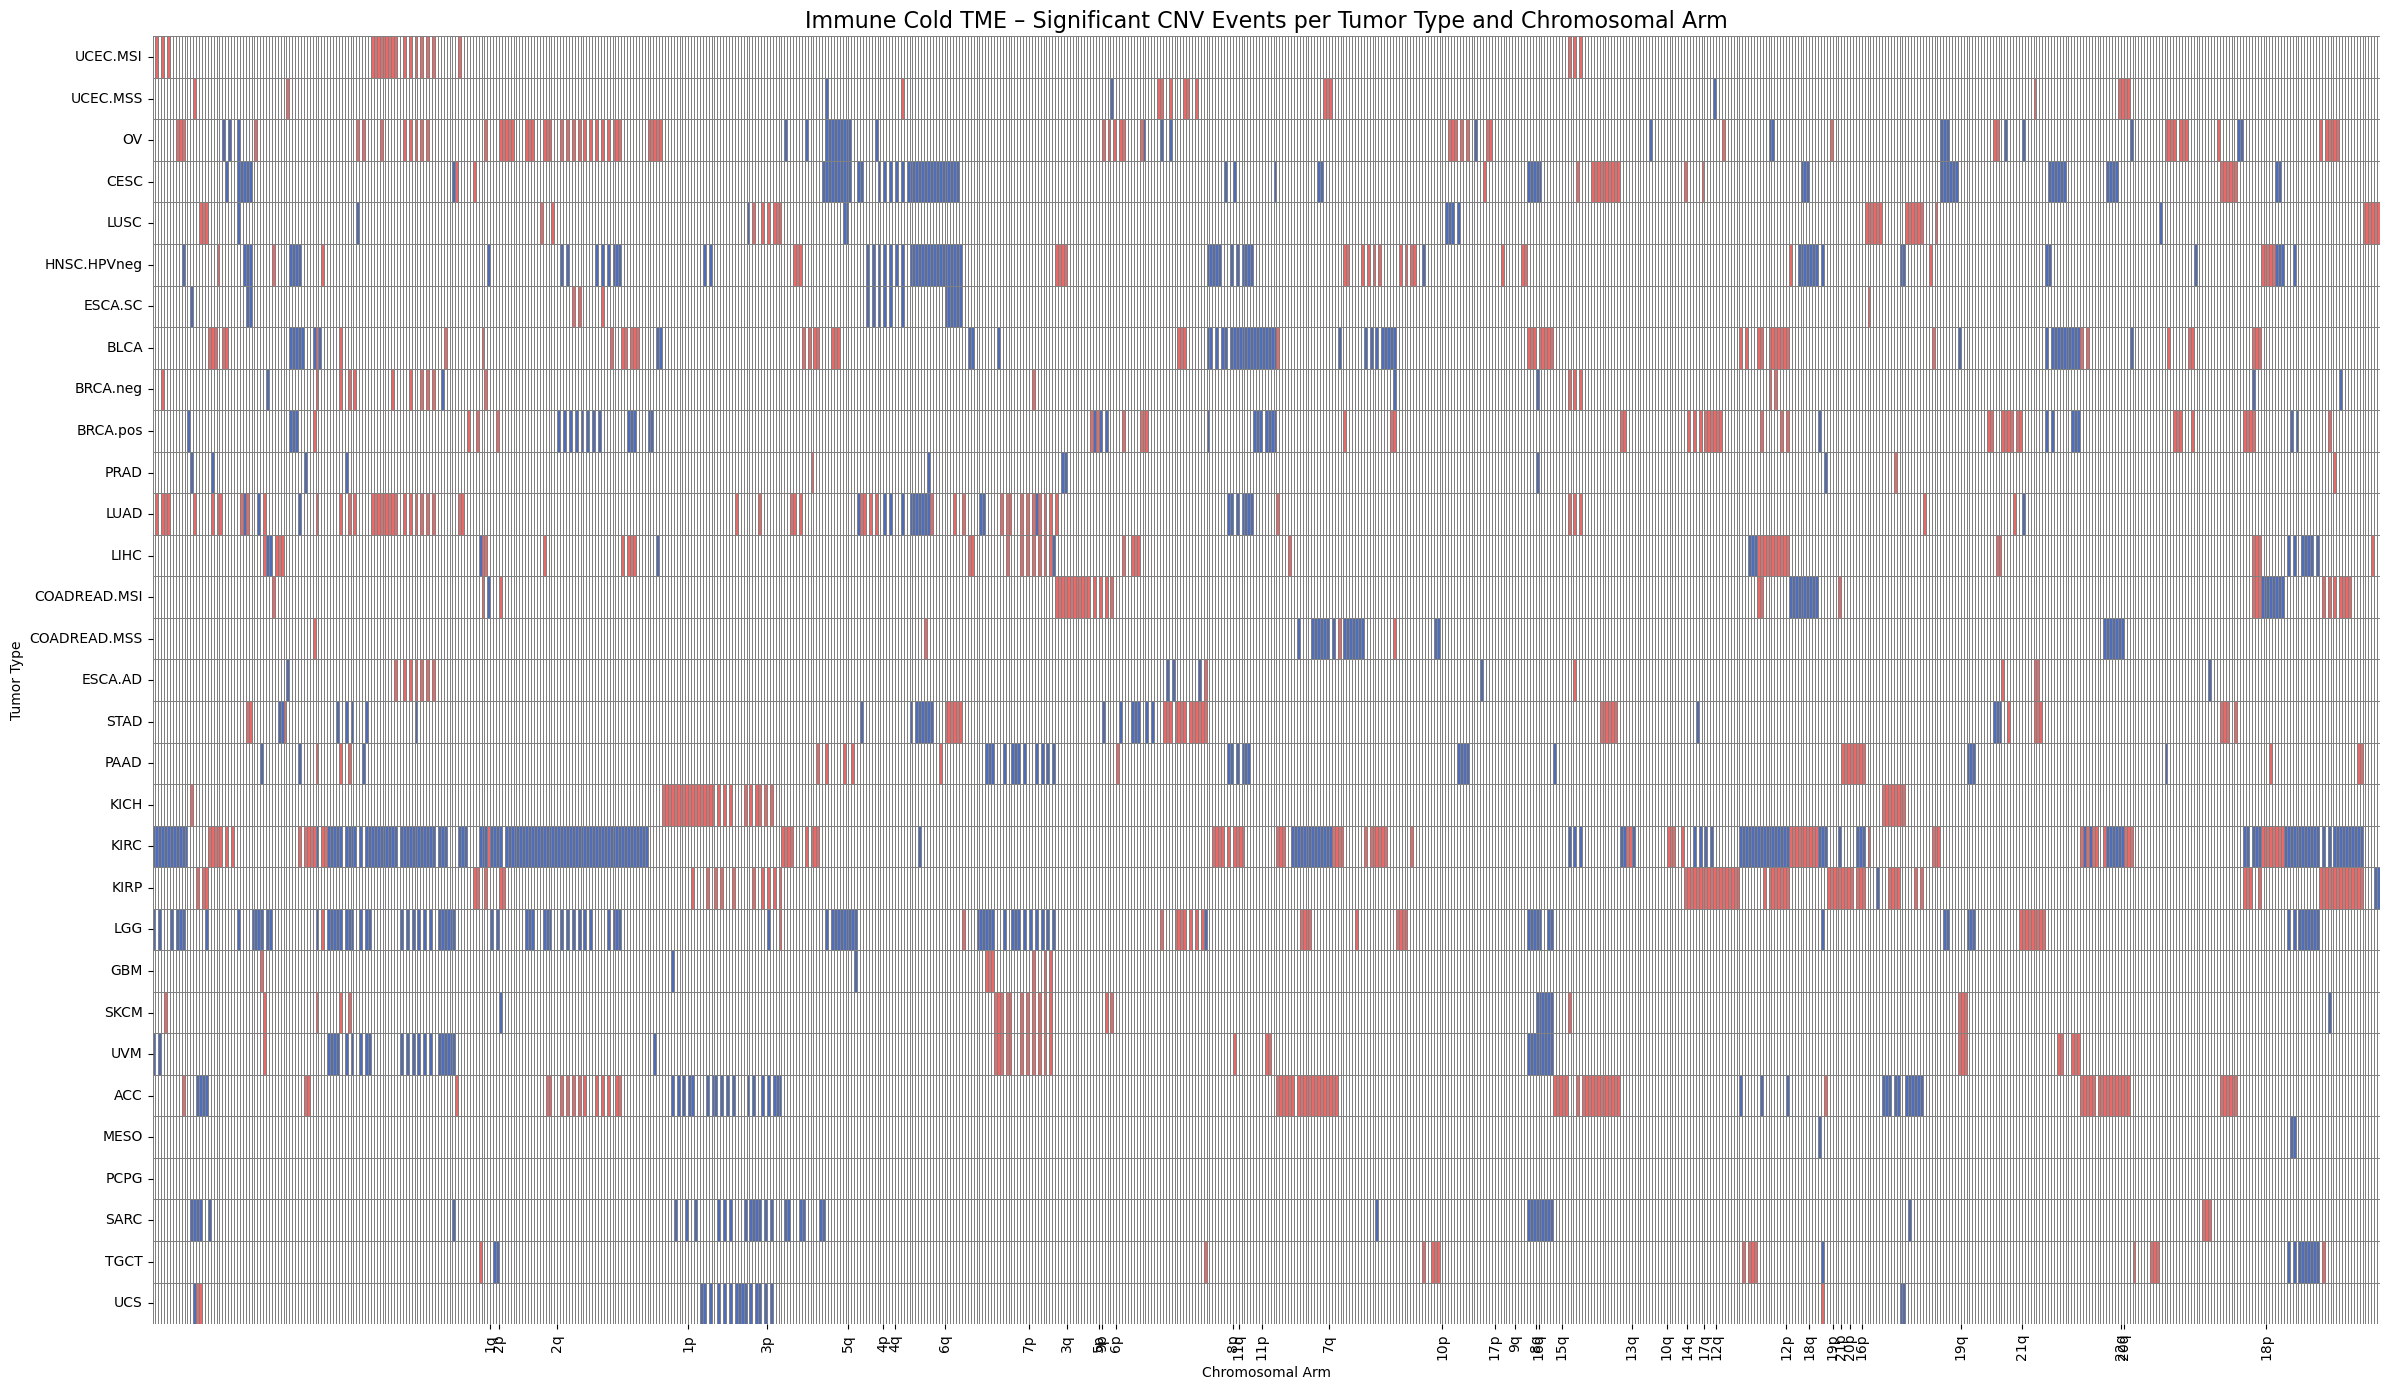

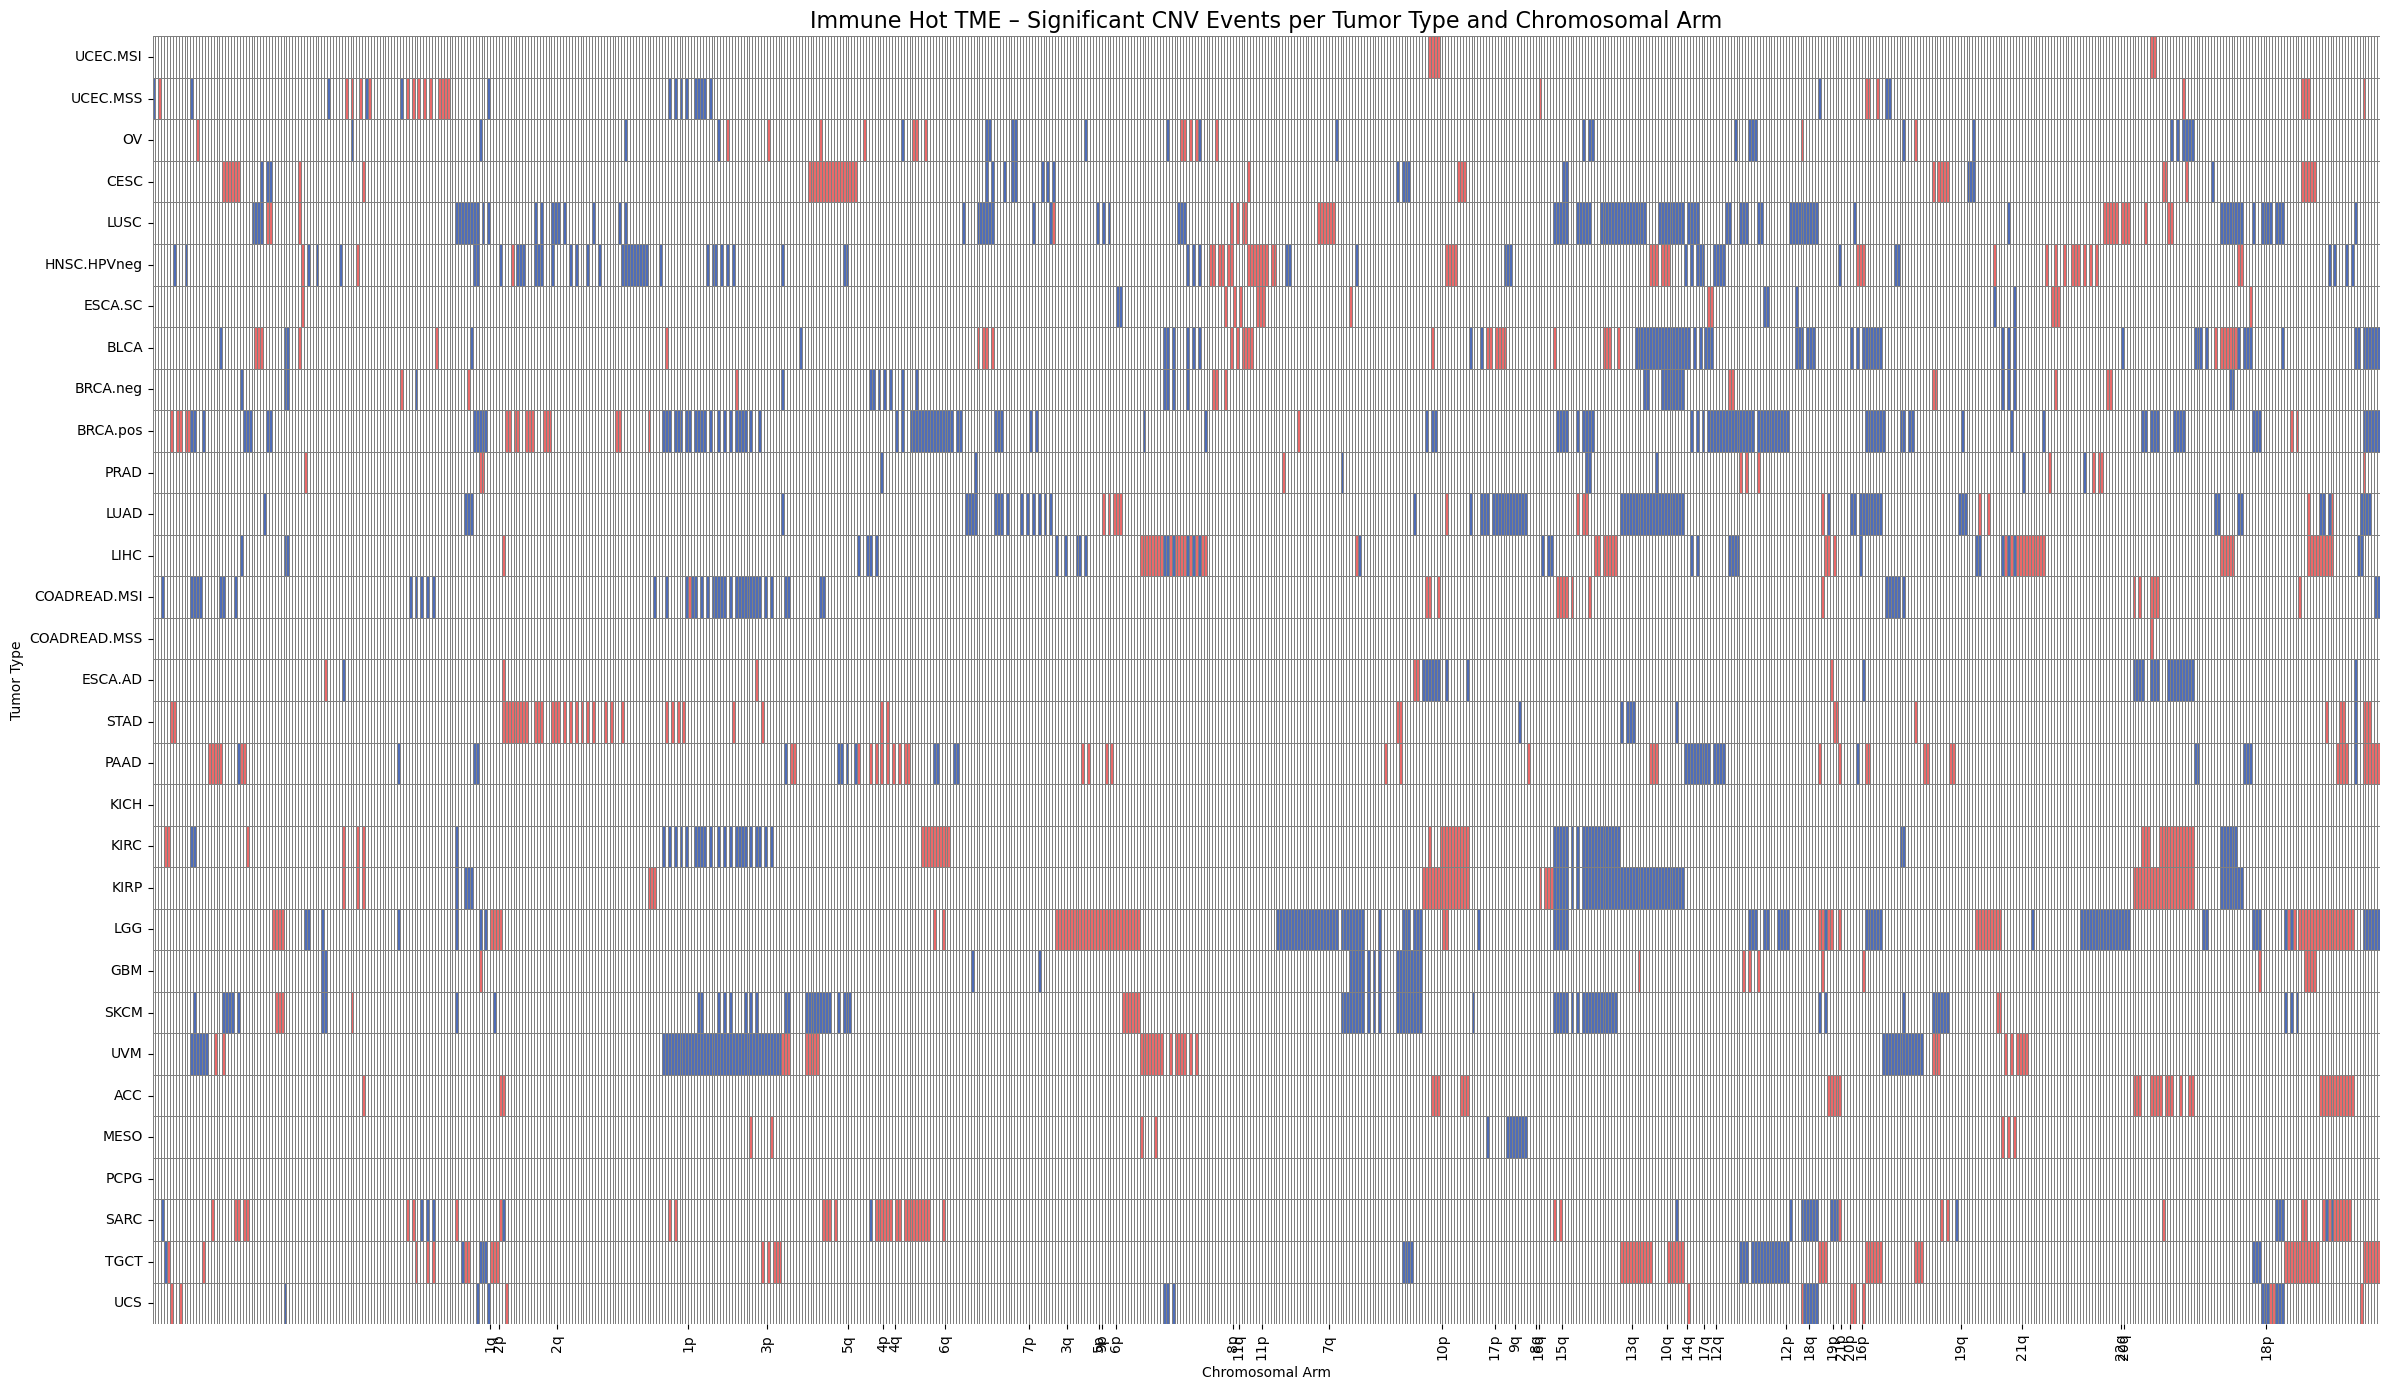

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

# STEP 1: Map cytoband → arm (e.g., "1p36.33" → "1p")
cytoband_to_arm = {band: re.match(r'^\d+[pq]', band).group(0) for band in all_cytobands}

# STEP 2: Get mapping from arms → cytoband indices
from collections import defaultdict

arm_to_indices = defaultdict(list)
for idx, band in enumerate(all_cytobands):
    arm = cytoband_to_arm[band]
    arm_to_indices[arm].append(idx)

# STEP 3: Compute midpoint for each arm (for clean x-axis tick)
arm_labels = []
arm_midpoints = []

for arm, indices in arm_to_indices.items():
    arm_labels.append(arm)
    arm_midpoints.append(int(np.mean(indices)))

# STEP 4: Plotting function
def plot_cytoband_heatmap(matrix, title):
    plt.figure(figsize=(24, 14))
    sns.heatmap(
        matrix.replace(0, float("nan")),
        cmap=sns.color_palette(["#4F6DB8", "#B8B8B8", "#EA6A6A"]),
        cbar=False,
        linewidths=0.4,
        linecolor='gray',
        center=0,
        xticklabels=False,
        yticklabels=True
    )

    # Add x-ticks at arm midpoints only
    plt.xticks(arm_midpoints, arm_labels, rotation=90)

    plt.title(title, fontsize=16)
    plt.xlabel("Chromosomal Arm")
    plt.ylabel("Tumor Type")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Plot for cold and hot CNVs
plot_cytoband_heatmap(cold_matrix, "Immune Cold TME – Significant CNV Events per Tumor Type and Chromosomal Arm")
plot_cytoband_heatmap(hot_matrix, "Immune Hot TME – Significant CNV Events per Tumor Type and Chromosomal Arm")

# Match cytoband

In [2]:
import pandas as pd

# Load CSV
top_cytobands = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Define tumor types shown in the figure (excluding BLCA and ESCA types)
tumor_types_in_figure = [
    "UCEC.MSI", "UCEC.MSS", "OV", "CESC", "LUSC", 
    "HNSC.HPVneg", "BRCA.neg", "BRCA.pos", "PRAD",
    "LUAD", "LIHC", "COADREAD.MSI", "COADREAD.MSS", 
    "STAD", "PAAD", "KICH", "KIRC", "KIRP", "LGG", "GBM", 
    "SKCM", "UVM", "ACC", "MESO", "PCPG", "UCS", "SARC", "TGCT"
]

# Filter to immune cold hits only and tumor types in figure
filtered_df = top_cytobands[
    (top_cytobands["TumorType"].isin(tumor_types_in_figure)) &
    (top_cytobands["AllHits"].notna())
]

# Subset to 1q gains and 9p losses
gain_1q = filtered_df[
    (filtered_df["AllHits"] == "Gain_ImmuneCold") & 
    (filtered_df["Cytoband"].str.startswith("1q"))
]

loss_9p = filtered_df[
    (filtered_df["AllHits"] == "Loss_ImmuneCold") & 
    (filtered_df["Cytoband"].str.startswith("9p"))
]

# Get top 5 cytobands with most tumor types
top_1q = gain_1q["Cytoband"].value_counts().head(5).index.tolist()
top_9p = loss_9p["Cytoband"].value_counts().head(5).index.tolist()

# Print tumor types for each
print("Top 1q Gains (Immune Cold):")
for band in top_1q:
    tumors = gain_1q[gain_1q["Cytoband"] == band]["TumorType"].unique()
    print(f"{band}: {', '.join(tumors)}")

print("\nTop 9p Losses (Immune Cold):")
for band in top_9p:
    tumors = loss_9p[loss_9p["Cytoband"] == band]["TumorType"].unique()
    print(f"{band}: {', '.join(tumors)}")

Top 1q Gains (Immune Cold):
1q21.1: BRCA.neg, LUAD, PAAD, SKCM
1q32.1: BRCA.neg, LUAD, OV, UCEC.MSI
1q21.2: BRCA.neg, LUAD, PAAD, SKCM
1q32.2: BRCA.neg, LUAD, OV, UCEC.MSI
1q42.11: BRCA.neg, LUAD, SKCM, UCEC.MSI

Top 9p Losses (Immune Cold):
9p24.2: HNSC.HPVneg, LUAD, PAAD
9p24.1: HNSC.HPVneg, LUAD, PAAD
9p23: HNSC.HPVneg, LUAD, PAAD
9p22.3: HNSC.HPVneg, LUAD, PAAD
9p22.2: HNSC.HPVneg, LUAD, PAAD


In [3]:
import pandas as pd

# Load the cytoband-level CNV data
top_cytobands = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Define a subset of tumor types (excluding BLCA and ESCA)
tumor_types_subset = ["UCEC.MSI", "OV", "BRCA.neg", "LUAD", "COADREAD.MSS"]

# Filter to only selected tumor types and non-null AllHits
filtered_df = top_cytobands[
    (top_cytobands["TumorType"].isin(tumor_types_subset)) &
    (top_cytobands["AllHits"].notna())
]

# Subset to 1q gains in immune cold tumors
gain_1q = filtered_df[
    (filtered_df["AllHits"] == "Gain_ImmuneCold") &
    (filtered_df["Cytoband"].str.startswith("1q"))
]

# Group by cytoband and list associated tumor types
gain_1q_results = gain_1q.groupby("Cytoband")["TumorType"].unique().sort_index()

# Print the results
for cytoband, tumors in gain_1q_results.items():
    print(f"{cytoband}: {', '.join(tumors)}")

1q21.1: BRCA.neg, LUAD
1q21.2: BRCA.neg, LUAD
1q21.3: BRCA.neg, LUAD
1q22: LUAD, UCEC.MSI
1q23.1: LUAD, UCEC.MSI
1q23.2: LUAD, UCEC.MSI
1q23.3: LUAD, UCEC.MSI
1q24.1: LUAD, OV, UCEC.MSI
1q24.2: LUAD, UCEC.MSI
1q24.3: LUAD, UCEC.MSI
1q25.1: LUAD, UCEC.MSI
1q25.2: BRCA.neg, LUAD, UCEC.MSI
1q25.3: LUAD, UCEC.MSI
1q31.1: LUAD, OV, UCEC.MSI
1q31.2: BRCA.neg, LUAD, OV, UCEC.MSI
1q31.3: LUAD, OV, UCEC.MSI
1q32.1: BRCA.neg, LUAD, OV, UCEC.MSI
1q32.2: BRCA.neg, LUAD, OV, UCEC.MSI
1q32.3: BRCA.neg, LUAD, UCEC.MSI
1q41: BRCA.neg, LUAD, UCEC.MSI
1q42.11: BRCA.neg, LUAD, UCEC.MSI
1q42.12: BRCA.neg, LUAD, UCEC.MSI
1q42.13: BRCA.neg, LUAD, UCEC.MSI
1q42.2: LUAD, UCEC.MSI
1q42.3: LUAD
1q43: LUAD
1q44: LUAD, UCEC.MSI


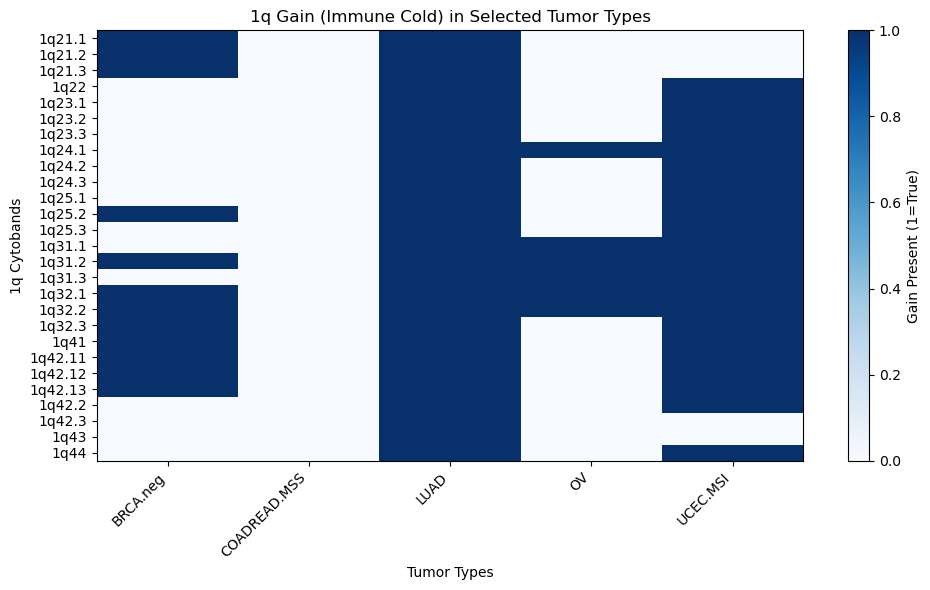

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
top_cytobands = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Tumor types to include
tumor_types_subset = ["UCEC.MSI", "OV", "BRCA.neg", "LUAD", "COADREAD.MSS"]

# Filter relevant entries
filtered_df = top_cytobands[
    (top_cytobands["TumorType"].isin(tumor_types_subset)) &
    (top_cytobands["AllHits"] == "Gain_ImmuneCold") &
    (top_cytobands["Cytoband"].str.startswith("1q"))
]

# Get unique lists
cytobands = sorted(filtered_df["Cytoband"].unique())
tumor_types = sorted(tumor_types_subset)

# Create binary matrix: rows = cytobands, columns = tumor types
matrix = pd.DataFrame(0, index=cytobands, columns=tumor_types)

for _, row in filtered_df.iterrows():
    matrix.loc[row["Cytoband"], row["TumorType"]] = 1

# Plot
plt.figure(figsize=(10, 6))
plt.imshow(matrix, cmap="Blues", aspect="auto")

# Labeling
plt.xticks(ticks=range(len(matrix.columns)), labels=matrix.columns, rotation=45, ha="right")
plt.yticks(ticks=range(len(matrix.index)), labels=matrix.index)
plt.xlabel("Tumor Types")
plt.ylabel("1q Cytobands")
plt.title("1q Gain (Immune Cold) in Selected Tumor Types")
plt.colorbar(label="Gain Present (1=True)")

plt.tight_layout()
plt.show()

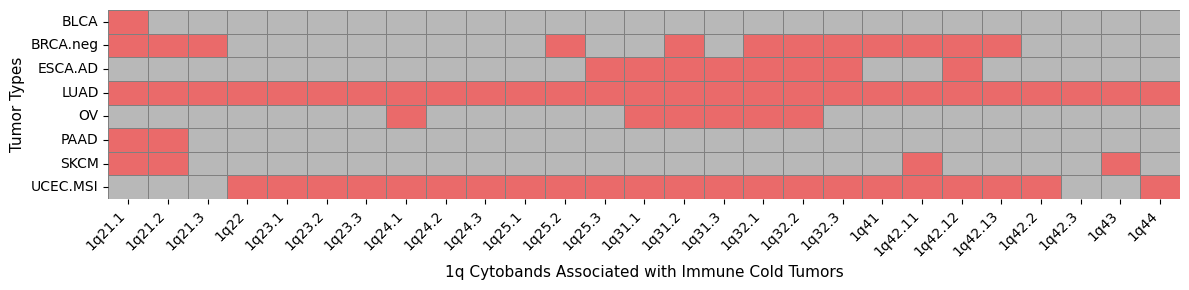

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Load the CSV
top_cytobands = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Tumor types to show (limit to 5 and exclude BLCA/ESCA)
tumor_types_subset = ["UCEC.MSI", "OV", "BLCA", "BRCA.neg", "LUAD", "ESCA.AD", "PAAD", "SKCM"]

# Filter to 1q gain in immune cold for those tumor types
filtered_df = top_cytobands[
    (top_cytobands["AllHits"] == "Gain_ImmuneCold") &
    (top_cytobands["Cytoband"].str.startswith("1q")) &
    (top_cytobands["TumorType"].isin(tumor_types_subset))
]

# Build binary matrix: TumorType (rows) vs Cytoband (cols)
cytobands = sorted(filtered_df["Cytoband"].unique())
tumors = sorted(tumor_types_subset)
matrix = pd.DataFrame(0, index=tumors, columns=cytobands)

# Fill 1s for gain events
for _, row in filtered_df.iterrows():
    matrix.loc[row["TumorType"], row["Cytoband"]] = 1

# Define custom color map: white (0) and pink (#EA6A6A) for gains
custom_cmap = ListedColormap(["#B8B8B8", "#EA6A6A"])

# Plot heatmap
plt.figure(figsize=(12, 3))
sns.heatmap(matrix, cmap=custom_cmap, cbar=False, linewidths=0.5, linecolor='gray')

# Styling
plt.xlabel("1q Cytobands Associated with Immune Cold Tumors", fontsize=11)
plt.ylabel("Tumor Types", fontsize=11)
# plt.title("1q Gains Associated with Immune Cold Tumors (Selected)", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../fig3c_1q.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [8]:
print(top_cytobands.columns)

Index(['MergeBy', 'TumorType', 'Cytoband', 'Event', 'Z_val', 'P_val',
       'ImmuneCold', 'ImmuneHot', 'has_diff_signs', 'Signif', 'ColdHits',
       'HotHits', 'AllHits', 'Cold_SignedLogP', 'Hot_SignedLogP'],
      dtype='object')


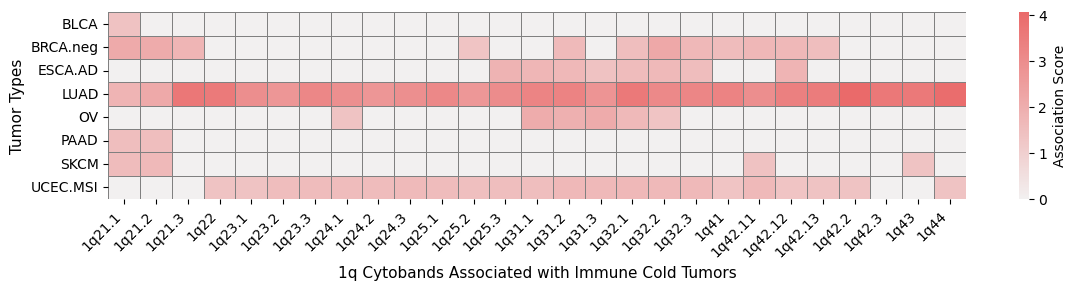

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
top_cytobands = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Selected tumor types (exclude BLCA/ESCA)
tumor_types_subset = ["UCEC.MSI", "OV", "BLCA", "BRCA.neg", "LUAD", "ESCA.AD", "PAAD", "SKCM"]

# Filter to 1q gains in immune cold tumors
filtered_df = top_cytobands[
    (top_cytobands["AllHits"] == "Gain_ImmuneCold") &
    (top_cytobands["Cytoband"].str.startswith("1q")) &
    (top_cytobands["TumorType"].isin(tumor_types_subset))
]

# Create a pivot table with the Score as the fill value (use actual column name, e.g., "Score" or "-log10(p)")
pivot = filtered_df.pivot(index="TumorType", columns="Cytoband", values="Cold_SignedLogP").fillna(0)

# Plot heatmap with continuous pink gradient
plt.figure(figsize=(12, 3))
sns.heatmap(
    pivot, 
    cmap=sns.light_palette("#EA6A6A", as_cmap=True), 
    linewidths=0.5, 
    linecolor='gray',
    cbar_kws={"label": "Association Score"}  # Optional colorbar label
)

# Styling
plt.xlabel("1q Cytobands Associated with Immune Cold Tumors", fontsize=11)
plt.ylabel("Tumor Types", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../fig3c_1q.pdf", format="pdf", bbox_inches="tight")
plt.show()

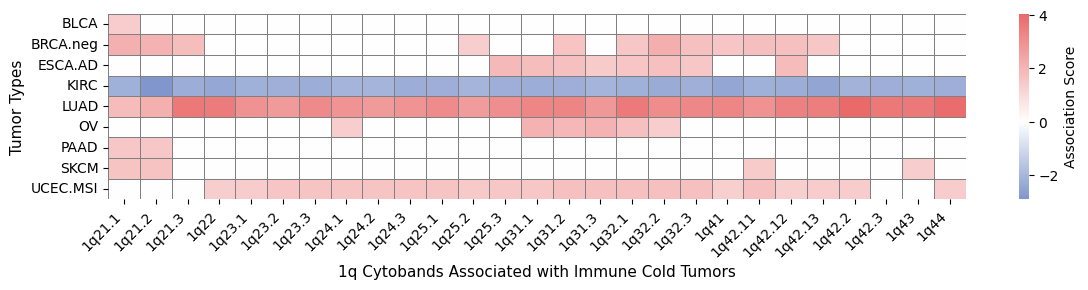

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Load data
top_cytobands = pd.read_csv(
    "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/TCGA/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv"
)

# Tumor types
tumor_types_subset = [
    "UCEC.MSI", "OV", "BLCA", "BRCA.neg", "LUAD", "ESCA.AD", "PAAD", "SKCM", "KIRC"
]

# Filter for both gain and loss immune cold on 1q
filtered_df = top_cytobands[
    (top_cytobands["AllHits"].isin(["Gain_ImmuneCold", "Loss_ImmuneCold"])) &
    (top_cytobands["Cytoband"].str.startswith("1q")) &
    (top_cytobands["TumorType"].isin(tumor_types_subset))
]

# Handle duplicates
filtered_df = filtered_df.groupby(["TumorType", "Cytoband"], as_index=False)["Cold_SignedLogP"].mean()

# Pivot
pivot = filtered_df.pivot(index="TumorType", columns="Cytoband", values="Cold_SignedLogP").fillna(0)

# ✅ Custom diverging colormap: blue → white → pink using exact hex
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging", ["#4F6DB8", "#FFFFFF", "#EA6A6A"], N=256
)

# Plot
plt.figure(figsize=(12, 3))
sns.heatmap(
    pivot,
    cmap=custom_cmap,
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Association Score"}
)

plt.xlabel("1q Cytobands Associated with Immune Cold Tumors", fontsize=11)
plt.ylabel("Tumor Types", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cytoband_heatmap+KIRC.pdf", format="pdf", bbox_inches="tight")
plt.show()

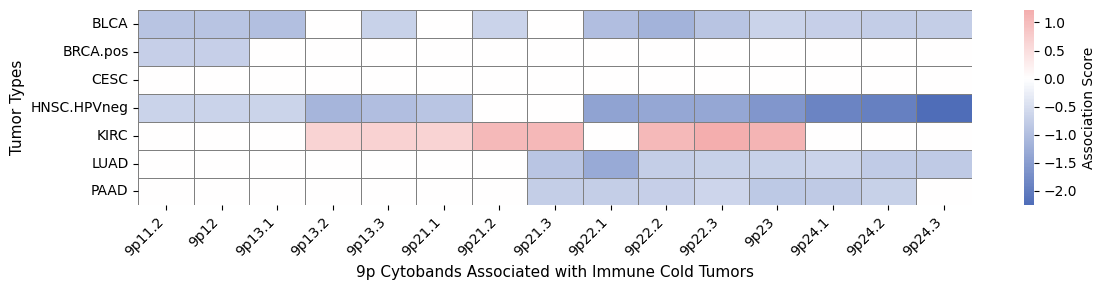

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Load the cytoband table
top_cytobands = pd.read_csv(
    "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/TCGA/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv"
)

# ✅ Tumor types including KIRC
tumor_types_subset = ["HNSC.HPVneg", "BLCA", "BRCA.pos", "LUAD", "PAAD", "CESC", "ESCA", "KIRC"]

# ✅ Filter by 9p cytobands only, include all tumor types in the list
filtered_df = top_cytobands[
    (top_cytobands["Cytoband"].str.startswith("9p")) &
    (top_cytobands["TumorType"].isin(tumor_types_subset))
]

# ✅ Handle duplicates by averaging Cold_SignedLogP if needed
filtered_df = filtered_df.groupby(["TumorType", "Cytoband"], as_index=False)["Cold_SignedLogP"].mean()

# ✅ Pivot for heatmap
pivot = filtered_df.pivot(index="TumorType", columns="Cytoband", values="Cold_SignedLogP").fillna(0)

# ✅ Use custom diverging colormap: blue (#4F6DB8) → white → pink (#EA6A6A)
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging", ["#4F6DB8", "#FFFFFF", "#EA6A6A"], N=256
)

# ✅ Plot
plt.figure(figsize=(12, 3))
sns.heatmap(
    pivot,
    cmap=custom_cmap,
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Association Score"}
)

# ✅ Styling
plt.xlabel("9p Cytobands Associated with Immune Cold Tumors", fontsize=11)
plt.ylabel("Tumor Types", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("heatmap_9p_with_KIRC.pdf", format="pdf", bbox_inches="tight")
plt.show()

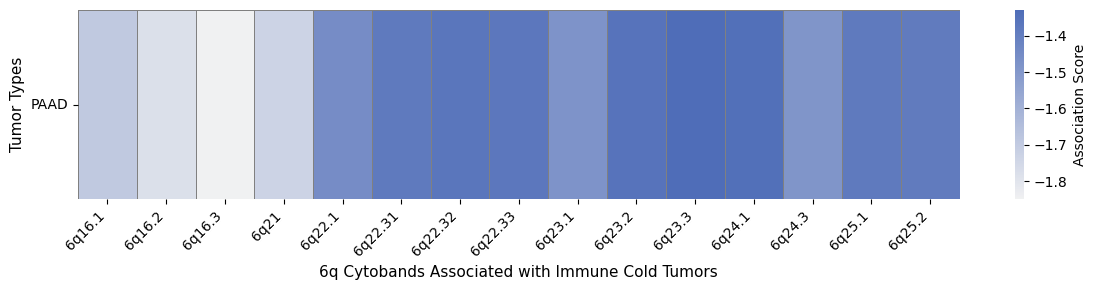

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
top_cytobands = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Selected tumor types 
tumor_types_subset = ["HNSC.HPVneg", "BLCA", "BRCA.pos", "LUAD", "PAAD", "CESC", "ESCA"]

# Filter to 6q losses in immune cold tumors
filtered_df = top_cytobands[
    (top_cytobands["AllHits"] == "Loss_ImmuneCold") &
    (top_cytobands["Cytoband"].str.startswith("6q")) &
    (top_cytobands["TumorType"].isin(tumor_types_subset))
]

# Create pivot table with signed -log10(p-value) as color intensity
pivot = filtered_df.pivot(index="TumorType", columns="Cytoband", values="Cold_SignedLogP").fillna(0)

# Plot heatmap with blue gradient (for 6q loss)
plt.figure(figsize=(12, 3))
sns.heatmap(
    pivot,
    cmap=sns.light_palette("#4F6DB8", as_cmap=True),  # blue tone
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Association Score"}
)

# Styling
plt.xlabel("6q Cytobands Associated with Immune Cold Tumors", fontsize=11)
plt.ylabel("Tumor Types", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

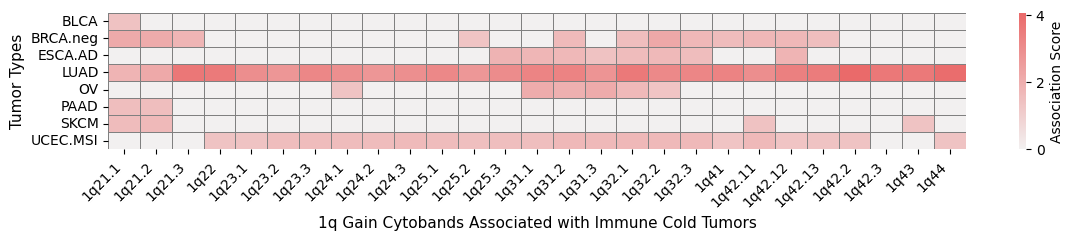

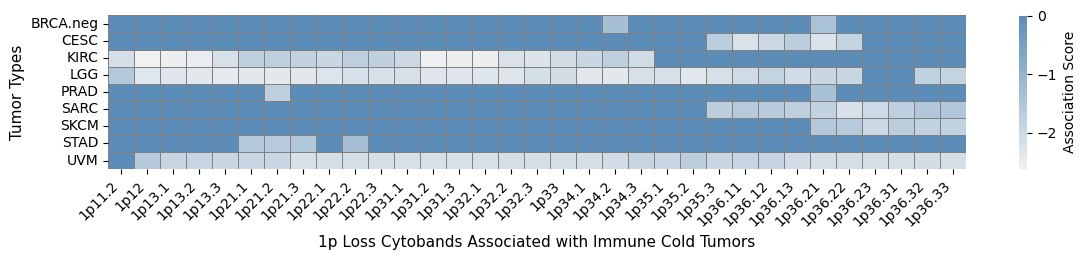

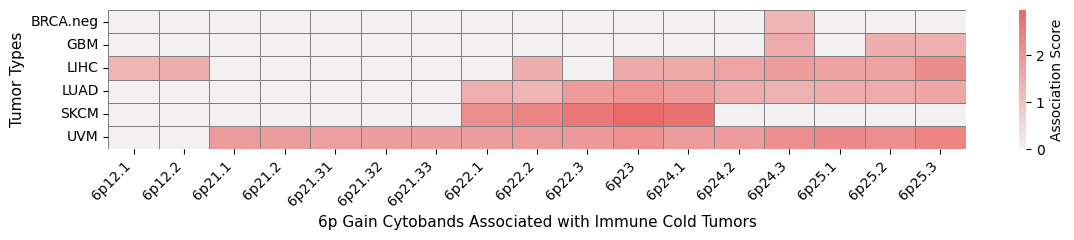

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
top_cytobands = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/Top_IS_Continuous_Cytoband_Hits/Continuous_Top_Cytobands_table.csv")

# Define plot function
def plot_cytoband_heatmap(df, title, output_path, cmap_color):
    pivot = df.pivot(index="TumorType", columns="Cytoband", values="Cold_SignedLogP").fillna(0)
    plt.figure(figsize=(12, max(2.5, 0.3 * len(pivot))))
    sns.heatmap(
        pivot,
        cmap=sns.light_palette(cmap_color, as_cmap=True),
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={"label": "Association Score"}
    )
    plt.xlabel(f"{title} Cytobands Associated with Immune Cold Tumors", fontsize=11)
    plt.ylabel("Tumor Types", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.show()

# 1q Gain + Immune Cold
df_1q_gain = top_cytobands[
    (top_cytobands["AllHits"] == "Gain_ImmuneCold") &
    (top_cytobands["Cytoband"].str.startswith("1q"))
]
plot_cytoband_heatmap(
    df_1q_gain,
    title="1q Gain",
    output_path="../fig_1q_gain.pdf",
    cmap_color="#EA6A6A"  # pink
)

# 1p Loss + Immune Cold
df_1p_loss = top_cytobands[
    (top_cytobands["AllHits"] == "Loss_ImmuneCold") &
    (top_cytobands["Cytoband"].str.startswith("1p"))
]
plot_cytoband_heatmap(
    df_1p_loss,
    title="1p Loss",
    output_path="../fig_1p_loss.pdf",
    cmap_color="#5B8DB8"  # blue
)

# 6p Gain + Immune Cold
df_6p_gain = top_cytobands[
    (top_cytobands["AllHits"] == "Gain_ImmuneCold") &
    (top_cytobands["Cytoband"].str.startswith("6p"))
]
plot_cytoband_heatmap(
    df_6p_gain,
    title="6p Gain",
    output_path="../fig_6p_gain.pdf",
    cmap_color="#EA6A6A"  # pink
)

In [ ]:
# After plotting each heatmap, save to PDF
plt.savefig("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/fig_1q_gain.pdf", format="pdf", bbox_inches="tight")
plt.savefig("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/fig_1p_loss.pdf", format="pdf", bbox_inches="tight")
plt.savefig("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/LK plots/fig_6p_gain.pdf", format="pdf", bbox_inches="tight")